In [1]:
#Project Name: IST 736 Final Project, Swift Analysis
#Project Author: Kent Roller 
#Project Creation Date: Febraury 15 2025
#Project Purpose: Point of view is that of a company wishing to enter the market of audio apps. 
#Specifically want to make an app that can play music based on the sentiment of the song versus 
#making an app that plays music based off of command structure: play X by Y. As such , want to make 
# a model that can accurately digest an artist discoragraphy via scrapper or other method to feed 
# into a preprocessing method and then into sentiment analysis tool. Once the sentiment analysis is 
# performed a model will be trained using the labels generated by the sentiment analysis in order 
# to perform labeling task for future release from the same artist. The overall idea would to have 
# a database in which each artist is stored along with their songs and labels, however for the intitial 
#prototyping the analysis will primarily be focused on the performance differences between the preprocessing 
#steps such as dictionary selection and sentiment tools used such as BERT or NLTK vs something like GoEmotion. 
# Once the most performant method has been found then model comparison can begin. 
# After a model is selected,if time allows a demo will be attempted that plugs into the application spotify
# and uses the labels for song list generation and request in the spotify app itself. 


In [2]:
#Needed to downgrade numpy in order to install tensorflow hub
#needed to install tensorflow hub in order to get BERT embeddings functional maybe
#attempting to call them via other means failed so resulted in this
!pip install numpy==1.23.5

In [3]:
import pandas as pd
import numpy as np

#import created dataset with lyrics
#Declare file path
file_path="C:/Users/super/OneDrive/Documents/IST736 Intro to Text Mining/swift_db.xlsx"

#Read file path
swift_db = pd.read_excel(file_path)

#print out first few observations and check import
print(swift_db.head(10))

      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  You booked the night train for a reason\nSo yo...  Taylor Swift   
1  It's been a long time\nAnd seeing the shape of...  Taylor Swift   
2  Break my soul in two looking for you\nBut you'...  Taylor Swift   
3  And the tennis court was covered up\nWith some...  Taylor Swift   
4  Hey, Dorothea, do you ever stop and think abou...  Taylor Swift   
5  Gray November\nI've been down since July\nMoti...  Taylor Swift   
6  Gleaming, twinkling\nEyes like sinking ships o...  Taylor Swift   
7  Honey, when I'm above the trees\nI see this fo...  Taylor Swif

In [4]:
#Ok. Time to start at the start
#First apply some regex to make sure the lyrics data is clean
import re 
#define function to remove pucntuation
def remove_punct(text):
    return re.sub(r'[^\w\s]', '', text)

#Apply function to lyrics column
swift_db["Lyrics"] = swift_db["Lyrics"].apply(remove_punct)

#Make second function to remove non ASCII characters if any
def no_asciiless(text): 
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    #And convert text to lower case
    text = text.lower().strip()
    return text

#Apply second function
swift_db["Lyrics"] = swift_db["Lyrics"].apply(no_asciiless)

#print head and make sure everything is as should be 
print(swift_db.head(10))




      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  you booked the night train for a reason\nso yo...  Taylor Swift   
1  its been a long time\nand seeing the shape of ...  Taylor Swift   
2  break my soul in two looking for you\nbut your...  Taylor Swift   
3  and the tennis court was covered up\nwith some...  Taylor Swift   
4  hey dorothea do you ever stop and think about ...  Taylor Swift   
5  gray november\nive been down since july\nmotio...  Taylor Swift   
6  gleaming twinkling\neyes like sinking ships on...  Taylor Swift   
7  honey when im above the trees\ni see this for ...  Taylor Swif

In [5]:
#Looks like the new line is still present in the lyrics, and \n probably wont tell us much in regards to 
#sentiment so need to find a way to remove this
def remove_newline(text):
    #replace newline charaters with a space instead
    text = re.sub(r'(\S)\n(\S)', r'\1 \2', text)
    #clean up and make sure no remaining \n left in data
    text = text.replace("\n", " ")
    #Make sure too many spaces werent added in the process
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

#Apply function to lyrics and see if the symbol has been removed
swift_db['Lyrics'] = swift_db["Lyrics"].apply(remove_newline)

#Check head and see if function worked as inteneded
print(swift_db.head(10))

      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  you booked the night train for a reason so you...  Taylor Swift   
1  its been a long time and seeing the shape of y...  Taylor Swift   
2  break my soul in two looking for you but youre...  Taylor Swift   
3  and the tennis court was covered up with some ...  Taylor Swift   
4  hey dorothea do you ever stop and think about ...  Taylor Swift   
5  gray november ive been down since july motion ...  Taylor Swift   
6  gleaming twinkling eyes like sinking ships on ...  Taylor Swift   
7  honey when im above the trees i see this for w...  Taylor Swif

In [6]:
#Heeey, alright, now we can move on to the next step
#We will do some basic EDA such as word frequency counts on average and by album 
#However to obtain frequncy counts will need words to be tokenized
#To begin will use NLTK stop words and tokenizer but will circle back to this point
#import nltk stuff
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')

#intialize nltk stopwords
nltk_stop_words = set(stopwords.words('english'))

#modify stop words list to include song section labels that are in the data
add_stopwords = {"pre-chorus", "chorus", "verse", "verse1", 'verse2', 'intro', 'outro', 'likechorus', 'likebridge', 'prechorus', 'bridge','postchorus'}
#update the stop words list
nltk_stop_words.update(add_stopwords)

#Define function to tokenize lyrics
def nltk_tokenize(text):
    words = word_tokenize(text)
    words = [word for word in words if word not in nltk_stop_words]
    return words

#Create new column with nltk tokenized text
swift_db["NLTK_Tokenized"] = swift_db["Lyrics"].apply(nltk_tokenize)

#Check to make sure columns are correct
print(swift_db.head(10))


C:\Users\super\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\super\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  you booked the night train for a reason so you...  Taylor Swift   
1  its been a long time and seeing the shape of y...  Taylor Swift   
2  break my soul in two looking for you but youre...  Taylor Swift   
3  and the tennis court was covered up with some ...  Taylor Swift   
4  hey dorothea do you ever stop and think about ...  Taylor Swift   
5  gray november ive been down since july motion ...  Taylor Swift   
6  gleaming twinkling eyes like sinking ships on ...  Taylor Swift   
7  honey when im above the trees i see this for w...  Taylor Swif

In [7]:
from collections import Counter
#Flatten list of words to obtain counts
nltk_discor_words = [word for words in swift_db['NLTK_Tokenized'] for word in words]

#Get top 10 word counts as artist total (counts across all albums)
nltk_discor_word_counts = Counter(nltk_discor_words)
nltk_top_10_words=nltk_discor_word_counts.most_common(10)

#convert to df to try to make table
nltk_discor_words_df = pd.DataFrame(nltk_top_10_words, columns=['Word', 'Count'])

print(nltk_discor_words_df)
#Need to edit stop word list to remove labels such as "chorus"

    Word  Count
0     im    450
1   like    428
2   know    385
3     oh    326
4  never    288
5   dont    284
6  youre    283
7   love    250
8     na    247
9   time    213


In [8]:
#Now to get the word counts across the albums individually 
album_nltk_word_counts = {}

#Make for loop to go through and get the top 10 words for each album
for album, group in swift_db.groupby('Album'):
    words= [word for lyrics in group['NLTK_Tokenized'] for word in lyrics]
    word_counts = Counter(words)
    top_words = word_counts.most_common(10)
    album_nltk_word_counts[album] = top_words
    
#Convert into df for ez viewing 
nltk_by_album_df = pd.DataFrame([
    #pull data from for loop extraction above
    {"Album": Album, "Word":word, "Count":count}
    for Album, words in album_nltk_word_counts.items()
    for word, count in words
])

#View the results
print(nltk_by_album_df)


           Album   Word  Count
0           1989     oh    100
1           1989   love     78
2           1989    yet     65
3           1989   wish     62
4           1989  shake     54
..           ...    ...    ...
85  Taylor Swift   dont     30
86  Taylor Swift    wan     26
87  Taylor Swift  think     26
88  Taylor Swift   back     25
89  Taylor Swift  never     25

[90 rows x 3 columns]


In [9]:
nltk_by_album_df

,Album,Word,Count
0,1989,oh,100
1,1989,love,78
2,1989,yet,65
3,1989,wish,62
4,1989,shake,54
...,...,...,...
85,Taylor Swift,dont,30
86,Taylor Swift,wan,26
87,Taylor Swift,think,26
88,Taylor Swift,back,25


In [10]:
pd.set_option('display.max_rows', None)
print(nltk_by_album_df)

           Album    Word  Count
0           1989      oh    100
1           1989    love     78
2           1989     yet     65
3           1989    wish     62
4           1989   shake     54
5           1989     got     46
6           1989    back     41
7           1989      go     39
8           1989   woods     38
9           1989   clear     38
10      Evermore      im     63
11      Evermore    know     49
12      Evermore    like     48
13      Evermore   could     26
14      Evermore   think     26
15      Evermore   youre     24
16      Evermore  taylor     22
17      Evermore   swift     22
18      Evermore    dont     21
19      Evermore    cant     21
20      Fearless    know     61
21      Fearless   youre     59
22      Fearless      im     51
23      Fearless    dont     36
24      Fearless      oh     36
25      Fearless    cant     29
26      Fearless   cause     27
27      Fearless   never     26
28      Fearless    like     25
29      Fearless    feel     22
30      

In [11]:
pd.reset_option('display.max_rows')

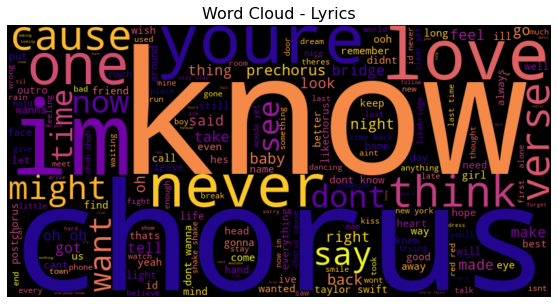

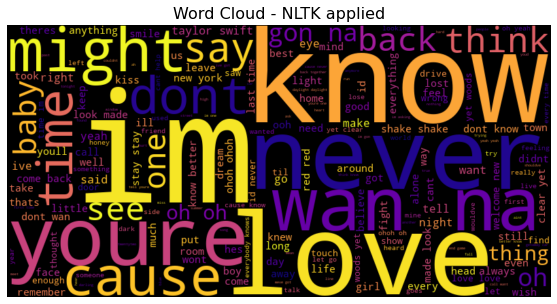

In [12]:
#Make a wordcloud comparing the tokenized text to the non tokenized raw text
#Make lyrics one long string
lyrics_cloud_text = " ".join(swift_db["Lyrics"])
#do the same with the tokenized words
nltk_cloud_text = " ".join([" ".join(words) for words in swift_db["NLTK_Tokenized"]])

#Can make a function to make the plots
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def cloud_maker(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color="black", colormap="plasma").generate(text)

    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()
    
#Use the function to make the word clouds
cloud_maker(lyrics_cloud_text, "Word Cloud - Lyrics")
cloud_maker(nltk_cloud_text, "Word Cloud - NLTK applied")

In [13]:
#Still need to edit the dictionary as it looks like prechorus still made it through in the second wordcloud
#That and likechorus, likebridge, postchorus, and bridge. 

#Dictionary updated and code reran
#Updated Dataset to include manual labels for both basic and complex sentiment analysis. 
#After data set was edited all code was rerun back to this point. 
#When running after the creation of this code step will not be necessary as changes are saved in the 
#df itself.

#Going to go ahead and make a third iteration of the above which will contain custom stop words only
custom_stop_words = {"pre-chorus", "chorus", "verse", "verse1", 'verse2', 'intro', 'outro', 'likechorus', 'likebridge', 'prechorus', 'bridge','postchorus', 'taylor swift'}

#Run tokenization again with custom stop words instead of nltk stop word list
#Define function to tokenize lyrics
def nltk_tokenize2(text):
    words = word_tokenize(text)
    words = [word for word in words if word not in custom_stop_words]
    return words

#Create new column with nltk tokenized text
swift_db["NLTK_Tokenized_Cstm_Stpwds"] = swift_db["Lyrics"].apply(nltk_tokenize2)

#Check to make sure columns are correct
print(swift_db.head(10)) 





      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  you booked the night train for a reason so you...  Taylor Swift   
1  its been a long time and seeing the shape of y...  Taylor Swift   
2  break my soul in two looking for you but youre...  Taylor Swift   
3  and the tennis court was covered up with some ...  Taylor Swift   
4  hey dorothea do you ever stop and think about ...  Taylor Swift   
5  gray november ive been down since july motion ...  Taylor Swift   
6  gleaming twinkling eyes like sinking ships on ...  Taylor Swift   
7  honey when im above the trees i see this for w...  Taylor Swif

In [14]:
#The reason we are making this split is that we want to observe if there is a difference in the performance 
# of the models, one with broad stopword removal and the other very specific. The reason being : 
# Sentiment analysis can be dependent on the full feature set, so removing words can actually hinder the 
# models performance instead of increasing it via dimensionality reduciton. To check this effect, 
# we will also be applying PCA to each of the feature sets to see if there is a difference between 
#which words have the most signifcance for the models. 
#Labeling information in part gathered from: https://taylorswiftsongs2.blogspot.com/p/song-meanings.html

#Flatten list of words to obtain counts as above
nltk_discor_words_cstm_stpwds = [word for words in swift_db['NLTK_Tokenized_Cstm_Stpwds'] for word in words]

#Get top 10 word counts as artist total (counts across all albums), will just do this for the comparison
nltk_discor_cstm_word_counts = Counter(nltk_discor_words_cstm_stpwds)
cstm_stpwds_top_10=nltk_discor_cstm_word_counts.most_common(10)

#convert to df to try to make table
cstm_stpwords_top10_df = pd.DataFrame(cstm_stpwds_top_10, columns=['Word', 'Count'])

print(cstm_stpwords_top10_df)

  Word  Count
0  you   2355
1    i   2151
2  the   1727
3  and   1405
4   me    882
5   to    867
6    a    839
7   it    748
8   in    736
9   my    725


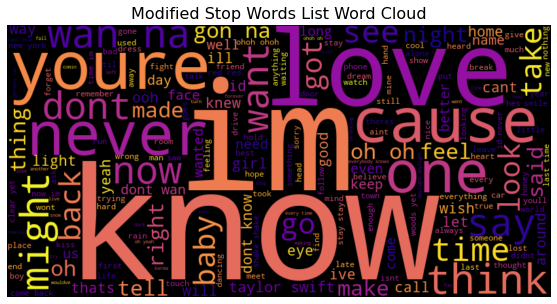

In [15]:
#Make a wordcloud comparing the tokenized text to the non tokenized raw text
#Make the modified stpwrd lyrics one long string
cstm_stpwds_cloud_text = " ".join([" ".join(words) for words in swift_db["NLTK_Tokenized_Cstm_Stpwds"]])
#Make word cloud for modified stop words list calling previosly made function
cloud_maker(cstm_stpwds_cloud_text, "Modified Stop Words List Word Cloud")


      index  Sentiment_Basic
0  negative               77
1  positive               60
Index(['Sentiment', 'Count'], dtype='object')


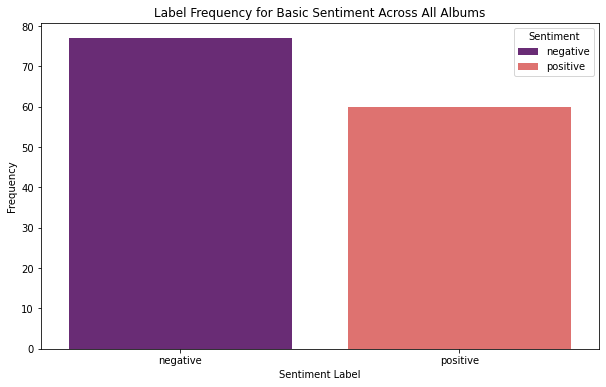

In [16]:
#Since labels have been added can do some quick visualizations with that as well before proceeding with 
#other tasks

#Strip spaces as there seems to be one positive observation that isnt cooperating
swift_db["Sentiment_Basic"] = swift_db["Sentiment_Basic"].str.strip()
swift_db["Sentiment_Advanced"] = swift_db["Sentiment_Advanced"].str.strip()
#Obtain class count for each label in the Sentiment columns 
bsc_sent_counts = swift_db["Sentiment_Basic"].value_counts()
adv_sent_counts = swift_db["Sentiment_Advanced"].value_counts()

#Convert to df for ease of plotting
bsc_sent_counts_df = bsc_sent_counts.reset_index()
adv_sent_counts_df = adv_sent_counts.reset_index()
#check step
print(bsc_sent_counts_df.head())

#define column names for counts data
bsc_sent_counts_df.columns = ["Sentiment", "Count"]
adv_sent_counts_df.columns = ["Sentiment", "Count"]
#Check step
print(bsc_sent_counts_df.columns)

#Make plots for counts
#plot for basic sentiment count across all albums
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x="Sentiment", y="Count", data=bsc_sent_counts_df, hue='Sentiment', palette='magma', dodge=False)
plt.title(f"Label Frequency for Basic Sentiment Across All Albums")
plt.ylabel('Frequency')
plt.xlabel('Sentiment Label')
plt.show() 

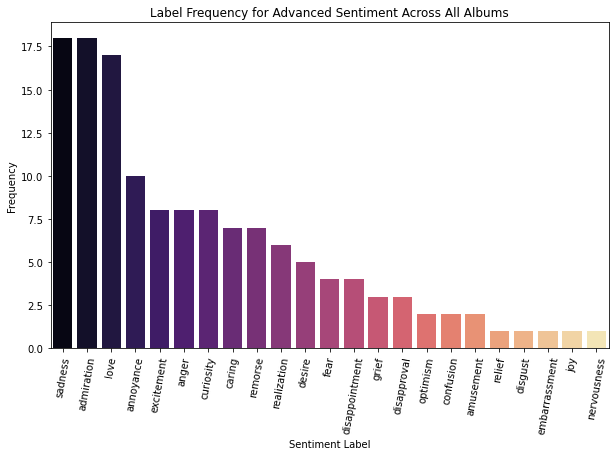

In [17]:
import seaborn as sns
plt.figure(figsize=(10,6))
#Make barplot for Advanced Sentiment
plt1 = sns.barplot(x="Sentiment", y="Count", data=adv_sent_counts_df, hue='Sentiment', palette='magma', dodge=False)
#Remove legend from the plot as it makes it cramped
plt.legend().remove()
#Add title and labels
plt.title(f"Label Frequency for Advanced Sentiment Across All Albums")
plt.ylabel('Frequency')
plt.xlabel('Sentiment Label')
#Rotate the x axis labels to make the more readable
plt.xticks(rotation=80)
#Show the plot
plt.show()

In [18]:
#apply tfidf vectorization and then figure out how to apply word2vec to compare the 
#weighting applied via each method.
#Apply automated sentiment labeling via BERT and GoEmotion before vectorizing
#Figure out staging
#Then apply the models of choice for making predictions of future albums 
#Use 10-fold cross validation

#Ok, first need to get sentiment labels through automation
#TO perform this task will use Bert and compare performance with GoEmotion. 
#Can attempt to apply tools on both raw text and tokenized data to determine differnece
#!pip install torch
#!pip install transformers
from transformers import pipeline 

#Load the models we want to use for sentiment labeling tasks
#Load BERT
bert_sent = pipeline("sentiment-analysis", model = "distilbert-base-uncased-finetuned-sst-2-english")
#Load GoEmotions
goemotions_sent = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=1)

#Define function to iterate through each of the songs and perform sentiment
# analysis on a per song basis 
#Need to add workaround to text length as apparently these tools have hard size limits
#RuntimeError: The size of tensor a (539) must match the size of tensor b (512) at non-singleton dimension 1
#This error indicates there is a size mismatch in the expected text(512) and the actual text
# which is sized at 539. Tensor A <= Tensor B for this to function.
#So we will add a hard character limit to the functions
#There is little fear in losing meaningful data from the songs by doing this as not all songs
# will be affected. Likewise, due to song structure words cut off at the end will likely be 
# a series of repetitions anyway so now new data will be lost. 
def bert_sentimizer(text):
    #restrict extraction of text to 512 characters
    text = str(text)[:512]
    #Extract results
    result = bert_sent(text)[0]
    #Return the score and sentiment label
    return result['label'], result['score']

#Apply function and make new columns to store sentiment data in 
swift_db['bert_sent_label'], swift_db["bert_sent_score"] = zip(*swift_db['Lyrics'].apply(bert_sentimizer))
#swift_db['goog_sent_label'], swift_db['goog_sent_score'] = zip(*swift_db['NLTK_Tokenized_Cstm_Stpwds'].apply(goog_sentimizer))

#Check data frame to see if data was included correctly 
print(swift_db.head(10))

Device set to use cpu
Device set to use cpu


      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  you booked the night train for a reason so you...  Taylor Swift   
1  its been a long time and seeing the shape of y...  Taylor Swift   
2  break my soul in two looking for you but youre...  Taylor Swift   
3  and the tennis court was covered up with some ...  Taylor Swift   
4  hey dorothea do you ever stop and think about ...  Taylor Swift   
5  gray november ive been down since july motion ...  Taylor Swift   
6  gleaming twinkling eyes like sinking ships on ...  Taylor Swift   
7  honey when im above the trees i see this for w...  Taylor Swif

In [19]:
#!pip install --upgrade typing_extensions

In [20]:
#GOemotion 
#Define another function but for GoEmotion
#This has to be setup different from the BERT model as this one cant use str as input
#as such have to create dictionary with observations not just a basic list
def goog_sentimizer(text):
    if isinstance(text, list):
        text = ' '.join(text)
    text = text[:512]
    result = goemotions_sent(text)
    #Fixing output stage to accomodate for data type 
    if isinstance(result, list) and len(result) > 0:
        first_result = result[0][0]
        label = first_result["label"]
        score = first_result['score']
        return label, score

swift_db['goog_sent_label'], swift_db['goog_sent_score'] = zip(*swift_db['Lyrics'].apply(goog_sentimizer))


In [21]:
#Check if results were obtained
print(swift_db.head(10))

      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  you booked the night train for a reason so you...  Taylor Swift   
1  its been a long time and seeing the shape of y...  Taylor Swift   
2  break my soul in two looking for you but youre...  Taylor Swift   
3  and the tennis court was covered up with some ...  Taylor Swift   
4  hey dorothea do you ever stop and think about ...  Taylor Swift   
5  gray november ive been down since july motion ...  Taylor Swift   
6  gleaming twinkling eyes like sinking ships on ...  Taylor Swift   
7  honey when im above the trees i see this for w...  Taylor Swif

In [22]:
swift_db['goog_sent_label_tkn'], swift_db['goog_sent_score_tkn'] = zip(*swift_db['NLTK_Tokenized_Cstm_Stpwds'].apply(goog_sentimizer))

In [23]:
print(swift_db.head(10))

      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  you booked the night train for a reason so you...  Taylor Swift   
1  its been a long time and seeing the shape of y...  Taylor Swift   
2  break my soul in two looking for you but youre...  Taylor Swift   
3  and the tennis court was covered up with some ...  Taylor Swift   
4  hey dorothea do you ever stop and think about ...  Taylor Swift   
5  gray november ive been down since july motion ...  Taylor Swift   
6  gleaming twinkling eyes like sinking ships on ...  Taylor Swift   
7  honey when im above the trees i see this for w...  Taylor Swif

In [24]:
#Hmmmm, the more I consider it the less I like just cutting observations when in 
#text classification every bit of information can make a difference in the outcome 
#of the model. 
#As such, will rerun GoEmotion sentiment analysis but this time will use method
#to split the text but still keep it associated with the a.) correct song title and, 
# b.) itself, so the full context of the song is retained for analysis. 
#If this makes a difference or not will be seen. 

#create function for splitting the text when it reaches a max length of 512 charaters
#This way we can work around the tensor size mismatch error which caused us to 
#run the model with a cap, and retain the full song for potentially higher accuracy
def split_text(text, max_length=512):
    return [text[i:i + max_length] for i in range(0, len(text), max_length)]

# Make function as before but need to make it work with the new chunks we made with 
# split_text above
def goog_sentimizer_no512(text):
    if isinstance(text, list):  
        text = ' '.join(text)
    #Storing the chunks so they can be used in the analysis
    text_chunks = split_text(text, max_length=512)  

    sentiment_labels = []
    sentiment_scores = []

    # Process each chunk separately
    for chunk in text_chunks:
        result = goemotions_sent(chunk)

        # Ensure result is not empty and correctly formatted
        if isinstance(result, list) and len(result) > 0 and isinstance(result[0], list) and len(result[0]) > 0:
            #pull results as dictionary in order to comply with GoEmotion formatting req
            first_result = result[0][0]
            #Store lable
            sentiment_labels.append(first_result["label"])
            #Store the score 
            sentiment_scores.append(first_result["score"])

    #If for some reason observation is empty fill it with something as to prevent error
    if len(sentiment_labels) == 0:  
        return "unknown", 0.0

    # Get most common sentiment label across chunks
    final_label = max(set(sentiment_labels), key=sentiment_labels.count)

    # Average confidence scores across chunks
    final_score = np.mean(sentiment_scores)

    return final_label, final_score

# Apply function to dataset storing the results in new columns in the df
swift_db['goog_sent_label_no512'], swift_db['goog_sent_score_no512'] = zip(*swift_db['Lyrics'].apply(goog_sentimizer_no512))

In [25]:
print(swift_db.head(10))

      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  you booked the night train for a reason so you...  Taylor Swift   
1  its been a long time and seeing the shape of y...  Taylor Swift   
2  break my soul in two looking for you but youre...  Taylor Swift   
3  and the tennis court was covered up with some ...  Taylor Swift   
4  hey dorothea do you ever stop and think about ...  Taylor Swift   
5  gray november ive been down since july motion ...  Taylor Swift   
6  gleaming twinkling eyes like sinking ships on ...  Taylor Swift   
7  honey when im above the trees i see this for w...  Taylor Swif

      index  bert_sent_label
0  NEGATIVE               77
1  POSITIVE               60
Index(['Sentiment', 'Count'], dtype='object')


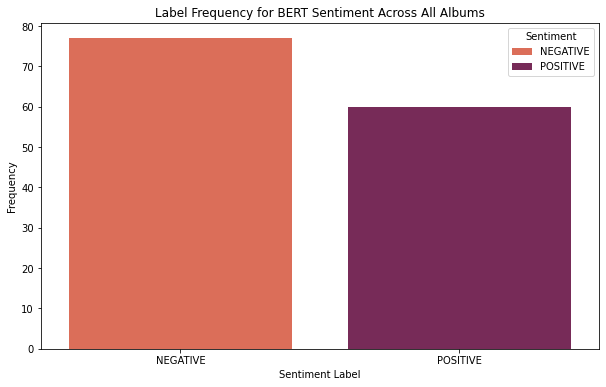

In [26]:
#Interesting, we have quite a bit of variation in between each of the variations of 
#the GoEmotion usage. Will need to make a comparison and see which is closer to the 
# "base" truth. 
#Lets make some more visualizations
#Obtain class count for each label in the Sentiment columns 
bert_sent_counts = swift_db["bert_sent_label"].value_counts()

#Convert to df for ease of plotting
bert_sent_counts_df = bert_sent_counts.reset_index()
#check step
print(bert_sent_counts_df.head())

#define column names for counts data
bert_sent_counts_df.columns = ["Sentiment", "Count"]
#Check step
print(bert_sent_counts_df.columns)

#Make plots for counts
#plot for basic sentiment count across all albums
plt.figure(figsize=(10,6))
sns.barplot(x="Sentiment", y="Count", data=bert_sent_counts_df, hue='Sentiment', palette='rocket_r', dodge=False)
plt.title(f"Label Frequency for BERT Sentiment Across All Albums")
plt.ylabel('Frequency')
plt.xlabel('Sentiment Label')
plt.show()

      index  goog_sent_label
0   sadness               45
1      fear               27
2  surprise               26
3       joy               21
4     anger               15
Index(['Sentiment', 'Count'], dtype='object')


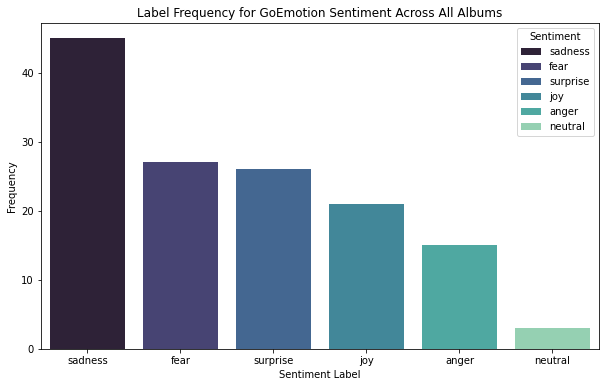

In [27]:
#Now make plots for GoEmotion Performance
#Lets make some more visualizations
#Obtain class count for each label in the Sentiment columns 
goog_sent_counts = swift_db["goog_sent_label"].value_counts()

#Convert to df for ease of plotting
goog_sent_counts_df = goog_sent_counts.reset_index()
#check step
print(goog_sent_counts_df.head())

#define column names for counts data
goog_sent_counts_df.columns = ["Sentiment", "Count"]
#Check step
print(goog_sent_counts_df.columns)

#Make plot
plt.figure(figsize=(10,6))
sns.barplot(x="Sentiment", y="Count", data=goog_sent_counts_df, hue='Sentiment', palette='mako', dodge=False)
plt.title(f"Label Frequency for GoEmotion Sentiment Across All Albums")
plt.ylabel('Frequency')
plt.xlabel('Sentiment Label')
plt.show()

      index  goog_sent_label_tkn
0   sadness                   39
1      fear                   29
2  surprise                   28
3       joy                   22
4     anger                   15
Index(['Sentiment', 'Count'], dtype='object')


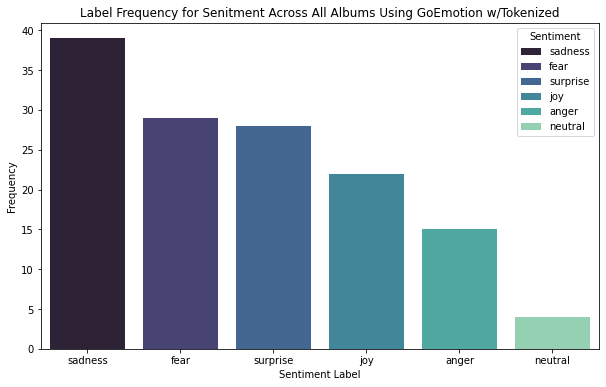

In [28]:
#Now need to make a plot for the GoEMotion using the tokenized data
#Obtain class count for each label in the Sentiment columns 
goog_tkn_sent_counts = swift_db["goog_sent_label_tkn"].value_counts()

#Convert to df for ease of plotting
goog_tkn_sent_counts_df = goog_tkn_sent_counts.reset_index()
#check step
print(goog_tkn_sent_counts_df.head())

#define column names for counts data
goog_tkn_sent_counts_df.columns = ["Sentiment", "Count"]
#Check step
print(goog_tkn_sent_counts_df.columns)

#Make plot
plt.figure(figsize=(10,6))
sns.barplot(x="Sentiment", y="Count", data=goog_tkn_sent_counts_df, hue='Sentiment', palette='mako', dodge=False)
plt.title(f"Label Frequency for Senitment Across All Albums Using GoEmotion w/Tokenized")
plt.ylabel('Frequency')
plt.xlabel('Sentiment Label')
plt.show()

      index  goog_sent_label_no512
0   sadness                     56
1  surprise                     25
2     anger                     19
3       joy                     18
4      fear                     15
Index(['Sentiment', 'Count'], dtype='object')


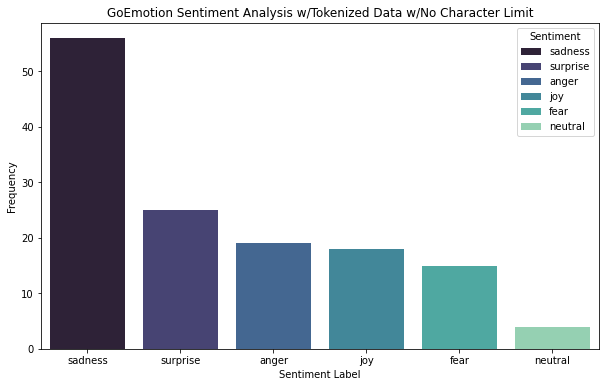

In [29]:
#And now need to make a plot for the tokenized but without the 512 character limit
#Obtain class count for each label in the Sentiment columns 
goog_no512_counts = swift_db["goog_sent_label_no512"].value_counts()

#Convert to df for ease of plotting
goog_no512_counts_df = goog_no512_counts.reset_index()
#check step
print(goog_no512_counts_df.head())

#define column names for counts data
goog_no512_counts_df.columns = ["Sentiment", "Count"]
#Check step
print(goog_no512_counts_df.columns)

#Make plot
plt.figure(figsize=(10,6))
sns.barplot(x="Sentiment", y="Count", data=goog_no512_counts_df, hue='Sentiment', palette='mako', dodge=False)
plt.title(f"GoEmotion Sentiment Analysis w/Tokenized Data w/No Character Limit")
plt.ylabel('Frequency')
plt.xlabel('Sentiment Label')
plt.show()

In [30]:
#Wellllllllllllllll
#I dont care for this
#Should have read the documentation before just using the tool
#Parameter needs to be tuned in order to match labels used 
#I.e. need to setup model to use all 27 emotions instead of 6
#However...this does beg the question what if we only used 6 labels instead?
#....may revisit this...am interested to know, what if. 

#For now, lets redo one of the models with all 27 labels in use by the model
#We will go with the no512 as it should have the largest amount of data
goemotions_full = pipeline("text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    # Ensures all emotions are considered
    top_k=27  
)

# Make function as before but need to make it work with the new chunks we made with 
# split_text above
#Changing the confidence threshold required to apply label
#However, case should be strongest label is still applied not first label
#I hope
def goog_sentimizer_full(text, confidence_threshold=0.01):
    if isinstance(text, list):  
        text = ' '.join(text)
    #Storing the chunks so they can be used in the analysis
    text_chunks = split_text(text, max_length=512)  

    sentiment_labels = []
    sentiment_scores = []

    # Process each chunk separately
    for chunk in text_chunks:
        result = goemotions_sent(chunk)

        # Ensure result is not empty and correctly formatted
        if isinstance(result, list) and len(result) > 0 and isinstance(result[0], list) and len(result[0]) > 0:
            #pull results as dictionary in order to comply with GoEmotion formatting req
            first_result = result[0][0]
            #Store lable
            sentiment_labels.append(first_result["label"])
            #Store the score 
            sentiment_scores.append(first_result["score"])

    #If for some reason observation is empty fill it with something as to prevent error
    if len(sentiment_labels) == 0:  
        return "unknown", 0.0

    # Get most common sentiment label across chunks
    final_label = max(set(sentiment_labels), key=sentiment_labels.count)

    # Average confidence scores across chunks
    final_score = np.mean(sentiment_scores)

    return final_label, final_score

# Apply function to dataset storing the results in new columns in the df
swift_db['goog_sent_label_full'], swift_db['goog_sent_score_full'] = zip(*swift_db['Lyrics'].apply(goog_sentimizer_full))

Device set to use cpu


In [31]:
print(swift_db.head(10))

      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  you booked the night train for a reason so you...  Taylor Swift   
1  its been a long time and seeing the shape of y...  Taylor Swift   
2  break my soul in two looking for you but youre...  Taylor Swift   
3  and the tennis court was covered up with some ...  Taylor Swift   
4  hey dorothea do you ever stop and think about ...  Taylor Swift   
5  gray november ive been down since july motion ...  Taylor Swift   
6  gleaming twinkling eyes like sinking ships on ...  Taylor Swift   
7  honey when im above the trees i see this for w...  Taylor Swif

      index  goog_sent_label_full
0   sadness                    56
1  surprise                    25
2     anger                    19
3       joy                    18
4      fear                    15
Index(['Sentiment', 'Count'], dtype='object')


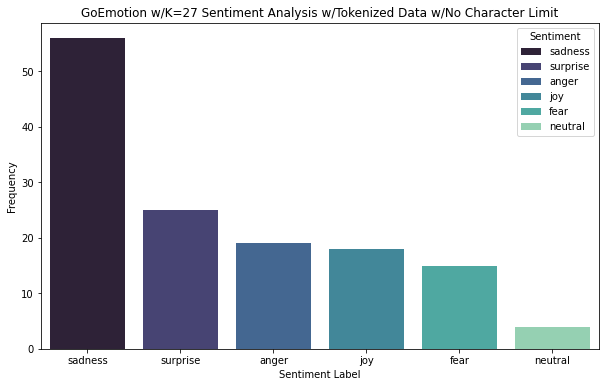

In [32]:
goog_full_counts = swift_db["goog_sent_label_full"].value_counts()

#Convert to df for ease of plotting
goog_full_counts_df = goog_full_counts.reset_index()
#check step
print(goog_full_counts_df.head())

#define column names for counts data
goog_full_counts_df.columns = ["Sentiment", "Count"]
#Check step
print(goog_full_counts_df.columns)

#Make plot
plt.figure(figsize=(10,6))
sns.barplot(x="Sentiment", y="Count", data=goog_full_counts_df, hue='Sentiment', palette='mako', dodge=False)
plt.title(f"GoEmotion w/K=27 Sentiment Analysis w/Tokenized Data w/No Character Limit")
plt.ylabel('Frequency')
plt.xlabel('Sentiment Label')
plt.show()

      index  Sentiment_Intermediate
0   sadness                      37
1       joy                      32
2      fear                      24
3  surprise                      23
4     anger                      16
Index(['Sentiment', 'Count'], dtype='object')


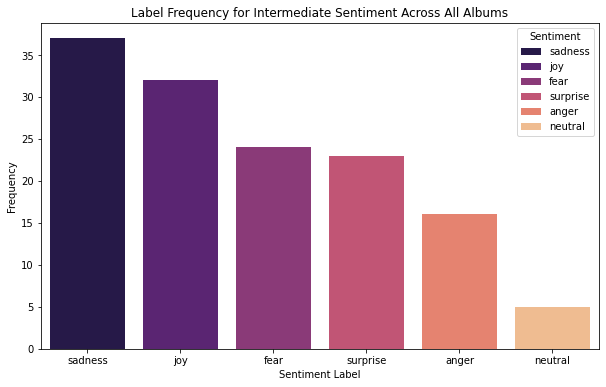

In [33]:
#Hmmmmm.......
#Edited dataset to accomodate 6 selections instead of 27
#Will come back to parameter tuning of the model to see if we can get it using all 27 labels. 
#The primary issue is in the way the weighting is performed 
#For now
#Make a plot of the 6 "ground truth" labels added to the data and see how they measure up

#Strip spaces as there seems to be one positive observation that isnt cooperating
swift_db["Sentiment_Intermediate"] = swift_db["Sentiment_Intermediate"].str.strip()
#Obtain class count for each label in the Sentiment columns 
inter_sent_counts = swift_db["Sentiment_Intermediate"].value_counts()

#Convert to df for ease of plotting
inter_sent_counts_df = inter_sent_counts.reset_index()

#check step
print(inter_sent_counts_df.head())

#define column names for counts data
inter_sent_counts_df.columns = ["Sentiment", "Count"]
#Check step
print(inter_sent_counts_df.columns)

#Make plots for counts
#plot for basic sentiment count across all albums
plt.figure(figsize=(10,6))
sns.barplot(x="Sentiment", y="Count", data=inter_sent_counts_df, hue='Sentiment', palette='magma', dodge=False)
plt.title(f"Label Frequency for Intermediate Sentiment Across All Albums")
plt.ylabel('Frequency')
plt.xlabel('Sentiment Label')
plt.show() 


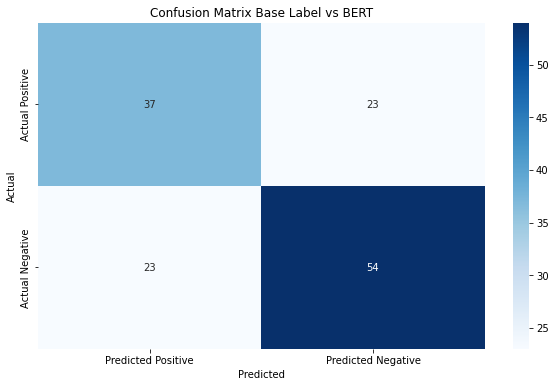

In [34]:
#Make confusion matrices to compare the base values against what has been done so far
#First will be the ground truth binary labels vs BERT
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
#Make sure labels are same case(BERT was all caps)
swift_db["Sentiment_Basic"] = swift_db["Sentiment_Basic"].str.lower()
#Do the same with the BERT column
swift_db["bert_sent_label"] = swift_db["bert_sent_label"].str.lower()

#Compute the matrix for the two columns above
confuse1 = confusion_matrix(swift_db["Sentiment_Basic"], swift_db["bert_sent_label"],
                           labels=["positive", "negative"])

#Make it a df so it cooperates with other things 
confuse1_df = pd.DataFrame(confuse1, index=["Actual Positive", "Actual Negative"],
                           columns=["Predicted Positive", "Predicted Negative"])

#Plot the df using seaborn to make a heatmap aka confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(confuse1_df, annot=True, fmt="d", cmap="Blues")
#Add labels 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Base Label vs BERT")
plt.show()


In [35]:
#Produce Report for the matrix
report1 = classification_report(swift_db["Sentiment_Basic"], swift_db["bert_sent_label"], labels=["positive", "negative"])
print("Classification Report:\n", report1)

# Display Accuracy
accuracy1 = accuracy_score(swift_db["Sentiment_Basic"], swift_db["bert_sent_label"])
print(f"Accuracy: {accuracy1:.2f}")

Classification Report:
               precision    recall  f1-score   support

    positive       0.62      0.62      0.62        60
    negative       0.70      0.70      0.70        77

    accuracy                           0.66       137
   macro avg       0.66      0.66      0.66       137
weighted avg       0.66      0.66      0.66       137

Accuracy: 0.66


In [36]:
print(swift_db['Sentiment_Basic'].unique())
print(swift_db['bert_sent_label'].unique())

['negative' 'positive']
['negative' 'positive']


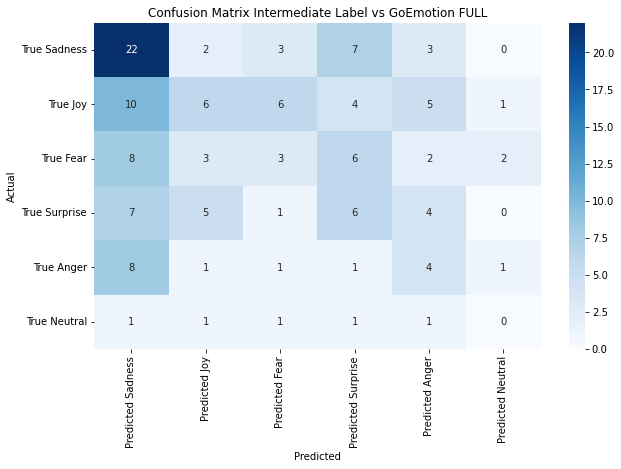

In [37]:
#Next will be the ground truth multiclass labels vs GoEmotion
#Make sure labels are same case(BERT was all caps)
swift_db["Sentiment_Intermediate"] = swift_db["Sentiment_Intermediate"].str.lower()
#Do the same with the goog_sent_full column
swift_db["goog_sent_label_full"] = swift_db["goog_sent_label_full"].str.lower()

#Compute the matrix for the two columns above
confuse1 = confusion_matrix(swift_db["Sentiment_Intermediate"], swift_db["goog_sent_label_full"],
                           labels=["sadness", 'joy', 'fear', 'surprise', 'anger', 'neutral'])

#Make it a df so it cooperates with other things 
confuse1_df = pd.DataFrame(confuse1, index=["True Sadness", "True Joy", "True Fear",
                                            "True Surprise", "True Anger", "True Neutral"],
                           columns=["Predicted Sadness", "Predicted Joy", "Predicted Fear", 
                                   "Predicted Surprise", "Predicted Anger", "Predicted Neutral"])


#Plot the df using seaborn to make a heatmap aka confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(confuse1_df, annot=True, fmt="d", cmap="Blues")
#Add labels 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Intermediate Label vs GoEmotion FULL")
plt.show()

In [38]:
#Produce Report
report2 = classification_report(swift_db["Sentiment_Intermediate"], swift_db["goog_sent_label_full"],
                                labels=["sadness", "joy", "fear", "surprise", "anger", "neutral"])
print("Classification Report:\n", report2)

# Display Accuracy
accuracy2 = accuracy_score(swift_db["Sentiment_Intermediate"], swift_db["goog_sent_label_full"])
print(f"Accuracy: {accuracy2:.2f}")

Classification Report:
               precision    recall  f1-score   support

     sadness       0.39      0.59      0.47        37
         joy       0.33      0.19      0.24        32
        fear       0.20      0.12      0.15        24
    surprise       0.24      0.26      0.25        23
       anger       0.21      0.25      0.23        16
     neutral       0.00      0.00      0.00         5

    accuracy                           0.30       137
   macro avg       0.23      0.24      0.22       137
weighted avg       0.28      0.30      0.28       137

Accuracy: 0.30


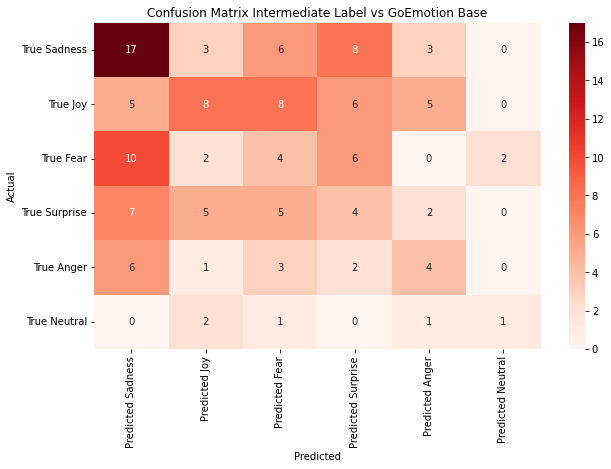

In [39]:
#Make matrices for the remaining methods, but comparing to sent_intermediate
#Make sure the goog_sent_full column mathces case with the intermediate one
swift_db["goog_sent_label"] = swift_db["goog_sent_label"].str.lower()

#Compute the matrix for the two columns above
confuse1 = confusion_matrix(swift_db["Sentiment_Intermediate"], swift_db["goog_sent_label"],
                           labels=["sadness", 'joy', 'fear', 'surprise', 'anger', 'neutral'])

#Make it a df so it cooperates with other things 
confuse1_df = pd.DataFrame(confuse1, index=["True Sadness", "True Joy", "True Fear",
                                            "True Surprise", "True Anger", "True Neutral"],
                           columns=["Predicted Sadness", "Predicted Joy", "Predicted Fear", 
                                   "Predicted Surprise", "Predicted Anger", "Predicted Neutral"])


#Plot the df using seaborn to make a heatmap aka confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(confuse1_df, annot=True, fmt="d", cmap="Reds")
#Add labels 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Intermediate Label vs GoEmotion Base")
plt.show()

In [40]:
#Produce Report
report3 = classification_report(swift_db["Sentiment_Intermediate"], swift_db["goog_sent_label"],
                                labels=["sadness", "joy", "fear", "surprise", "anger", "neutral"])
print("Classification Report:\n", report3)

# Display Accuracy
accuracy3 = accuracy_score(swift_db["Sentiment_Intermediate"], swift_db["goog_sent_label"])
print(f"Accuracy: {accuracy3:.2f}")

Classification Report:
               precision    recall  f1-score   support

     sadness       0.38      0.46      0.41        37
         joy       0.38      0.25      0.30        32
        fear       0.15      0.17      0.16        24
    surprise       0.15      0.17      0.16        23
       anger       0.27      0.25      0.26        16
     neutral       0.33      0.20      0.25         5

    accuracy                           0.28       137
   macro avg       0.28      0.25      0.26       137
weighted avg       0.29      0.28      0.28       137

Accuracy: 0.28


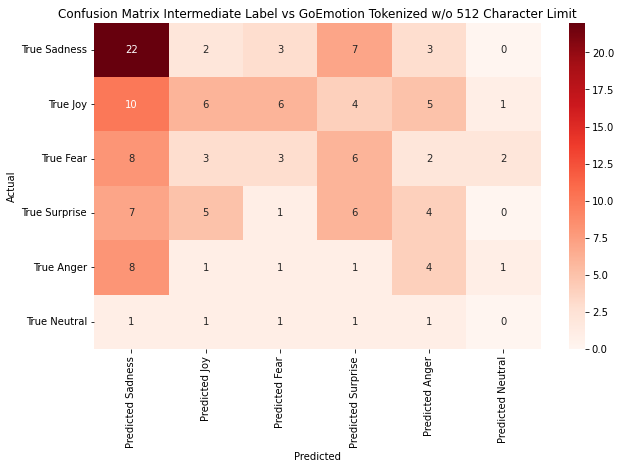

In [41]:
#Make matrix for the 512 cutoff removal
swift_db["goog_sent_label_no512"] = swift_db["goog_sent_label_no512"].str.lower()

#Compute the matrix for the two columns above
confuse1 = confusion_matrix(swift_db["Sentiment_Intermediate"], swift_db["goog_sent_label_no512"],
                           labels=["sadness", 'joy', 'fear', 'surprise', 'anger', 'neutral'])

#Make it a df so it cooperates with other things 
confuse1_df = pd.DataFrame(confuse1, index=["True Sadness", "True Joy", "True Fear",
                                            "True Surprise", "True Anger", "True Neutral"],
                           columns=["Predicted Sadness", "Predicted Joy", "Predicted Fear", 
                                   "Predicted Surprise", "Predicted Anger", "Predicted Neutral"])


#Plot the df using seaborn to make a heatmap aka confusion matrix
plt.figure(figsize=(10,6))
sns.heatmap(confuse1_df, annot=True, fmt="d", cmap="Reds")
#Add labels 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Intermediate Label vs GoEmotion Tokenized w/o 512 Character Limit")
plt.show()

In [42]:
report4 = classification_report(swift_db["Sentiment_Intermediate"], swift_db["goog_sent_label_no512"],
                                labels=["sadness", "joy", "fear", "surprise", "anger", "neutral"])
print("Classification Report:\n", report4)

# Display Accuracy
accuracy4 = accuracy_score(swift_db["Sentiment_Intermediate"], swift_db["goog_sent_label_no512"])
print(f"Accuracy: {accuracy4:.2f}")

Classification Report:
               precision    recall  f1-score   support

     sadness       0.39      0.59      0.47        37
         joy       0.33      0.19      0.24        32
        fear       0.20      0.12      0.15        24
    surprise       0.24      0.26      0.25        23
       anger       0.21      0.25      0.23        16
     neutral       0.00      0.00      0.00         5

    accuracy                           0.30       137
   macro avg       0.23      0.24      0.22       137
weighted avg       0.28      0.30      0.28       137

Accuracy: 0.30


In [43]:
print(swift_db.head(10))

      Album         Song Title  \
0  Evermore  champagneproblems   
1  Evermore            closure   
2  Evermore        coneyisland   
3  Evermore       cowboylikeme   
4  Evermore           dorothea   
5  Evermore           evermore   
6  Evermore           goldrush   
7  Evermore          happiness   
8  Evermore                ivy   
9  Evermore     longstoryshort   

                                              Lyrics        Artist  \
0  you booked the night train for a reason so you...  Taylor Swift   
1  its been a long time and seeing the shape of y...  Taylor Swift   
2  break my soul in two looking for you but youre...  Taylor Swift   
3  and the tennis court was covered up with some ...  Taylor Swift   
4  hey dorothea do you ever stop and think about ...  Taylor Swift   
5  gray november ive been down since july motion ...  Taylor Swift   
6  gleaming twinkling eyes like sinking ships on ...  Taylor Swift   
7  honey when im above the trees i see this for w...  Taylor Swif

In [44]:
#Need to use tf-idf or other vectorizers on the custom stop words data. 
#once this is applied can make models and compare baseline performance of models to sentiment analysis tools. 
#First need to import MNB model, the vecotrizer and the cross validation method
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score, LeaveOneOut

#Call the text data into a new variable to keep from editing column in df
mnb_text = swift_db["Lyrics"]

#Set label for testing, for initial pass will use binary labels, will run second model with expanded labels
y = swift_db["Sentiment_Basic"]

#Call the vectorizer
tfidf_vec = TfidfVectorizer()
#Apply vectorizer to the text data
mnb_vect = tfidf_vec.fit_transform(mnb_text)

#Initialize the model
mnb_model1 = MultinomialNB()

#Want to compare both 10 fold and n-1 fold cross validation on the data
#Reason being is the dataset is small and want to know if performance difference exists 
#between cross validation methods as a result. 
mnb_10_cv_scores = cross_val_score(mnb_model1, mnb_vect, y, cv=10, scoring="accuracy")

#Make loo model
loo = LeaveOneOut()
mnb_loo_scores = cross_val_score(mnb_model1, mnb_vect, y, cv=loo, scoring="accuracy")

#Calculate mean accuracy across both models 
mean_mnb_10fold = np.mean(mnb_10_cv_scores)
mean_mnb_loo = np.mean(mnb_loo_scores)

#Print the results and compare models 
print(f"10-Fold Cross Validation Mean Accuracy: {mean_mnb_10fold:.4f}")
print(f"Leave One Out Cross Validation Mean Accuracy: {mean_mnb_loo:.4f}")



10-Fold Cross Validation Mean Accuracy: 0.5615
Leave One Out Cross Validation Mean Accuracy: 0.5620


In [45]:
#Now do the same but using the intermediate labels instead of the basic (binary sentiment) labels

#Call the other label here, all the other code can be reused 
y = swift_db["Sentiment_Intermediate"]

#Call the vectorizer
tfidf_vec = TfidfVectorizer()
#Apply vectorizer to the text data
mnb_vect = tfidf_vec.fit_transform(mnb_text)

#Initialize the model
mnb_model1 = MultinomialNB()

#Want to compare both 10 fold and n-1 fold cross validation on the data
#Reason being is the dataset is small and want to know if performance difference exists 
#between cross validation methods as a result. 
mnb_10_cv_scores = cross_val_score(mnb_model1, mnb_vect, y, cv=10, scoring="accuracy")

#Make loo model
loo = LeaveOneOut()
mnb_loo_scores = cross_val_score(mnb_model1, mnb_vect, y, cv=loo, scoring="accuracy")

#Calculate mean accuracy across both models 
mean_mnb_10fold_int = np.mean(mnb_10_cv_scores)
mean_mnb_loo_int = np.mean(mnb_loo_scores)

#Print the results and compare models 
print(f"10-Fold Cross Validation Mean Accuracy: {mean_mnb_10fold_int:.4f}")
print(f"Leave One Out Cross Validation Mean Accuracy: {mean_mnb_loo_int:.4f}")

C:\Users\super\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


10-Fold Cross Validation Mean Accuracy: 0.2758
Leave One Out Cross Validation Mean Accuracy: 0.2482


In [46]:
#Rerun but this time set some parameters in the vectorizer to see if performance can be improved
#Call the text data into a new variable to keep from editing column in df
mnb_text = swift_db["Lyrics"]

#Set label for testing, for initial pass will use binary labels, will run second model with expanded labels
y = swift_db["Sentiment_Basic"]

#Call the vectorizer
tfidf_vec = TfidfVectorizer(
    #Use ngrams
    ngram_range=(1,2),
    #Intialize stopwords since cant use tokenized data
    stop_words='english',
    #change how many words to ignore, will set fairly high
    #The issue with this parameter and limited data means may degrade performance with its inclusion
    max_df = 0.70
)
#Apply vectorizer to the text data
mnb_vect = tfidf_vec.fit_transform(mnb_text)

#Initialize the model
mnb_model1 = MultinomialNB()

#Want to compare both 10 fold and n-1 fold cross validation on the data
#Reason being is the dataset is small and want to know if performance difference exists 
#between cross validation methods as a result. 
mnb_10_cv_scores = cross_val_score(mnb_model1, mnb_vect, y, cv=10, scoring="accuracy")

#Make loo model
loo = LeaveOneOut()
mnb_loo_scores = cross_val_score(mnb_model1, mnb_vect, y, cv=loo, scoring="accuracy")

#Calculate mean accuracy across both models 
mean_mnb_10fold_param = np.mean(mnb_10_cv_scores)
mean_mnb_loo_param = np.mean(mnb_loo_scores)

#Print the results and compare models 
print(f"10-Fold Cross Validation Mean Accuracy: {mean_mnb_10fold_param:.4f}")
print(f"Leave One Out Cross Validation Mean Accuracy: {mean_mnb_loo_param:.4f}")

10-Fold Cross Validation Mean Accuracy: 0.5615
Leave One Out Cross Validation Mean Accuracy: 0.5620


In [47]:
#And its identical to the previous results meaning parameter tuning wasnt the issue. 
#With text data like this every word matters in terms of context, so MNB may not be the best fit
#since it assumes independence for words in a "document" and in our case the words may very much so be 
#dependent on one another. 
#Next, we will see if SVM offers better performance out of the box or with minimal tuning when compared
# to MNB. 

#First need to import SVM, or SVC as it is in this case for this type of problem. 
from sklearn.svm import SVC

#And from here most of the code is similar to before
#Call the text data into a new variable to keep from editing column in df
mnb_text = swift_db["Lyrics"]

#Set label for testing, for initial pass will use binary labels, will run second model with expanded labels
y = swift_db["Sentiment_Basic"]

#Call the vectorizer
tfidf_vec = TfidfVectorizer()
#Apply vectorizer to the text data
mnb_vect = tfidf_vec.fit_transform(mnb_text)

#Initialize the SVC model instead of the MNB model
svm_model = SVC(kernel="linear", C=1.0)

#Want to compare both 10 fold and n-1 fold cross validation on the data
#Reason being is the dataset is small and want to know if performance difference exists 
#between cross validation methods as a result. 
svm_10_cv_scores = cross_val_score(svm_model, mnb_vect, y, cv=10, scoring="accuracy")

#Make loo model
loo = LeaveOneOut()
svm_loo_scores = cross_val_score(svm_model, mnb_vect, y, cv=loo, scoring="accuracy")

#Calculate mean accuracy across both models 
mean_svm_10fold = np.mean(svm_10_cv_scores)
mean_svm_loo = np.mean(svm_loo_scores)

#Print the results and compare models 
print(f"10-Fold Cross Validation Mean Accuracy: {mean_svm_10fold:.4f}")
print(f"Leave One Out Cross Validation Mean Accuracy: {mean_svm_loo:.4f}")


10-Fold Cross Validation Mean Accuracy: 0.6505
Leave One Out Cross Validation Mean Accuracy: 0.5912


In [48]:
#And now apply the model to the expanded data labels to see if any improvement over MNB is to be had

#And from here most of the code is similar to before
#Call the text data into a new variable to keep from editing column in df
mnb_text = swift_db["Lyrics"]

#Set label for testing, for initial pass will use binary labels, will run second model with expanded labels
y = swift_db["Sentiment_Intermediate"]

#Call the vectorizer
tfidf_vec = TfidfVectorizer()
#Apply vectorizer to the text data
mnb_vect = tfidf_vec.fit_transform(mnb_text)

#Initialize the SVC model instead of the MNB model
svm_model = SVC(kernel="linear", C=1.0)

#Want to compare both 10 fold and n-1 fold cross validation on the data
#Reason being is the dataset is small and want to know if performance difference exists 
#between cross validation methods as a result. 
svm_10_cv_scores = cross_val_score(svm_model, mnb_vect, y, cv=10, scoring="accuracy")

#Make loo model
loo = LeaveOneOut()
svm_loo_scores = cross_val_score(svm_model, mnb_vect, y, cv=loo, scoring="accuracy")

#Calculate mean accuracy across both models 
mean_svm_10fold_inter = np.mean(svm_10_cv_scores)
mean_svm_loo_inter = np.mean(svm_loo_scores)

#Print the results and compare models 
print(f"10-Fold Cross Validation Mean Accuracy: {mean_svm_10fold_inter:.4f}")
print(f"Leave One Out Cross Validation Mean Accuracy: {mean_svm_loo_inter:.4f}")

C:\Users\super\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


10-Fold Cross Validation Mean Accuracy: 0.3071
Leave One Out Cross Validation Mean Accuracy: 0.2993


In [49]:
#Terrible performance as before. Can run some different values of C as a form of parameter tuning to 
# see if any uplift is to be had
#First need to import SVM, or SVC as it is in this case for this type of problem. 
from sklearn.svm import SVC

#And from here most of the code is similar to before
#Call the text data into a new variable to keep from editing column in df
mnb_text = swift_db["Lyrics"]

#Set label for testing, for initial pass will use binary labels, will run second model with expanded labels
y = swift_db["Sentiment_Basic"]

#Call the vectorizer
tfidf_vec = TfidfVectorizer()
#Apply vectorizer to the text data
mnb_vect = tfidf_vec.fit_transform(mnb_text)

#Initialize the SVC model instead of the MNB model
svm_model = SVC(kernel="linear", C=0.5)

#Want to compare both 10 fold and n-1 fold cross validation on the data
#Reason being is the dataset is small and want to know if performance difference exists 
#between cross validation methods as a result. 
svm_10_cv_scores = cross_val_score(svm_model, mnb_vect, y, cv=10, scoring="accuracy")

#Make loo model
loo = LeaveOneOut()
svm_loo_scores = cross_val_score(svm_model, mnb_vect, y, cv=loo, scoring="accuracy")

#Calculate mean accuracy across both models 
mean_svm_10fold_c1 = np.mean(svm_10_cv_scores)
mean_svm_loo_c1 = np.mean(svm_loo_scores)

#Print the results and compare models 
print(f"10-Fold Cross Validation Mean Accuracy: {mean_svm_10fold_c1:.4f}")
print(f"Leave One Out Cross Validation Mean Accuracy: {mean_svm_loo_c1:.4f}")

10-Fold Cross Validation Mean Accuracy: 0.5615
Leave One Out Cross Validation Mean Accuracy: 0.5620


In [50]:
#Weird, dropping the value resulted in the same accuracy that we acheived with the MNB model. 
#Attempt to do some parameter tuning with the model
#One thing we will attempt to do is follow this assumption:regularization parameter is always assumed
#to be proprotional to 1/sqrt(n_samples). Here we have ~110 samples, so 1/sqrt(110)=~0.09. However, 
#I wonder if that should be adjusted if accounting for cv...
#First need to import SVM, or SVC as it is in this case for this type of problem. 


#And from here most of the code is similar to before
#Call the text data into a new variable to keep from editing column in df
mnb_text = swift_db["Lyrics"]

#Set label for testing, for initial pass will use binary labels, will run second model with expanded labels
y = swift_db["Sentiment_Basic"]

#Call the vectorizer
tfidf_vec = TfidfVectorizer()
#Apply vectorizer to the text data
mnb_vect = tfidf_vec.fit_transform(mnb_text)

#Initialize the SVC model instead of the MNB model
svm_model = SVC(kernel="linear", C=0.09)

#Want to compare both 10 fold and n-1 fold cross validation on the data
#Reason being is the dataset is small and want to know if performance difference exists 
#between cross validation methods as a result. 
svm_10_cv_scores = cross_val_score(svm_model, mnb_vect, y, cv=10, scoring="accuracy")

#Make loo model
loo = LeaveOneOut()
svm_loo_scores = cross_val_score(svm_model, mnb_vect, y, cv=loo, scoring="accuracy")

#Calculate mean accuracy across both models 
mean_svm_10fold = np.mean(svm_10_cv_scores)
mean_svm_loo = np.mean(svm_loo_scores)

#Print the results and compare models 
print(f"10-Fold Cross Validation Mean Accuracy: {mean_svm_10fold:.4f}")
print(f"Leave One Out Cross Validation Mean Accuracy: {mean_svm_loo:.4f}")

10-Fold Cross Validation Mean Accuracy: 0.5615
Leave One Out Cross Validation Mean Accuracy: 0.5620


In [51]:
#First need to import SVM, or SVC as it is in this case for this type of problem. 
from sklearn.svm import SVC

#And from here most of the code is similar to before
#Call the text data into a new variable to keep from editing column in df
mnb_text = swift_db["Lyrics"]

#Set label for testing, for initial pass will use binary labels, will run second model with expanded labels
y = swift_db["Sentiment_Basic"]

#Call the vectorizer
tfidf_vec = TfidfVectorizer()
#Apply vectorizer to the text data
mnb_vect = tfidf_vec.fit_transform(mnb_text)

#Initialize the SVC model instead of the MNB model
svm_model = SVC(kernel="linear", C=0.95)

#Want to compare both 10 fold and n-1 fold cross validation on the data
#Reason being is the dataset is small and want to know if performance difference exists 
#between cross validation methods as a result. 
svm_10_cv_scores = cross_val_score(svm_model, mnb_vect, y, cv=10, scoring="accuracy")

#Make loo model
loo = LeaveOneOut()
svm_loo_scores = cross_val_score(svm_model, mnb_vect, y, cv=loo, scoring="accuracy")

#Calculate mean accuracy across both models 
mean_svm_10fold = np.mean(svm_10_cv_scores)
mean_svm_loo = np.mean(svm_loo_scores)

#Print the results and compare models 
print(f"10-Fold Cross Validation Mean Accuracy: {mean_svm_10fold:.4f}")
print(f"Leave One Out Cross Validation Mean Accuracy: {mean_svm_loo:.4f}")

10-Fold Cross Validation Mean Accuracy: 0.6577
Leave One Out Cross Validation Mean Accuracy: 0.5839


In [52]:
#First need to import SVM, or SVC as it is in this case for this type of problem. 
from sklearn.svm import SVC

#And from here most of the code is similar to before
#Call the text data into a new variable to keep from editing column in df
mnb_text = swift_db["Lyrics"]

#Set label for testing, for initial pass will use binary labels, will run second model with expanded labels
y = swift_db["Sentiment_Basic"]

#Call the vectorizer
tfidf_vec = TfidfVectorizer()
#Apply vectorizer to the text data
mnb_vect = tfidf_vec.fit_transform(mnb_text)

#Initialize the SVC model instead of the MNB model
svm_model = SVC(kernel="linear", C=0.90)

#Want to compare both 10 fold and n-1 fold cross validation on the data
#Reason being is the dataset is small and want to know if performance difference exists 
#between cross validation methods as a result. 
svm_10_cv_scores = cross_val_score(svm_model, mnb_vect, y, cv=10, scoring="accuracy")

#Make loo model
loo = LeaveOneOut()
svm_loo_scores = cross_val_score(svm_model, mnb_vect, y, cv=loo, scoring="accuracy")

#Calculate mean accuracy across both models 
mean_svm_10fold = np.mean(svm_10_cv_scores)
mean_svm_loo = np.mean(svm_loo_scores)

#Print the results and compare models 
print(f"10-Fold Cross Validation Mean Accuracy: {mean_svm_10fold:.4f}")
print(f"Leave One Out Cross Validation Mean Accuracy: {mean_svm_loo:.4f}")

10-Fold Cross Validation Mean Accuracy: 0.6352
Leave One Out Cross Validation Mean Accuracy: 0.5766


In [53]:
#Attempt to use LinearSVC instead of just SVC to see if there is any performance difference between the two
#The difference if any may be minimal since the dataset is so small and the SVC model was using the linear
# kernel
#Use Linear SVC First
#Then make embeddings 
#Then try to apply a more complex model to see if some kind of reasonable accuracy can be acheived 
 
from sklearn.svm import LinearSVC
#Set up vectorizer
tfidf_vec = TfidfVectorizer()
#put lyrics in variable 
svc_text = swift_db["Lyrics"]
#Call basic labels for first pass to use as Y
y = swift_db["Sentiment_Basic"]
#Transfrom lyrics using vectorizer
svc_vect = tfidf_vec.fit_transform(svc_text)

#Initialize Linear SVC model
svc_model = LinearSVC(C=1.0, max_iter=5000)

#Run both 10 fold and n-1 fold cross validation on LinearSVC
svc_10_cv_scores = cross_val_score(svc_model, svc_vect, y, cv=10, scoring="accuracy")

#Leave one out test
loo = LeaveOneOut()
svc_cv_loo_scores = cross_val_score(svc_model, svc_vect, y, cv=loo, scoring="accuracy")

#Calculate means 
mean_10_fold_svc = np.mean(svc_10_cv_scores)
mean_loo_fold_svc=np.mean(svc_cv_loo_scores)

#Print the results of both models
print(f"LinearSVC 10-Fold Cross Validation Accuracy: {mean_10_fold_svc:.4f}")
print(f"LinearSVC LOO Fold Cross Validation Accuracy: {mean_loo_fold_svc:.4f}")

LinearSVC 10-Fold Cross Validation Accuracy: 0.6137
LinearSVC LOO Fold Cross Validation Accuracy: 0.5693


In [54]:
#Now to use the same model but this time y will be the Intermediate Sentiment
#Call basic labels for first pass to use as Y
y = swift_db["Sentiment_Intermediate"]
#Transfrom lyrics using vectorizer
svc_vect = tfidf_vec.fit_transform(svc_text)

#Initialize Linear SVC model
svc_model = LinearSVC(C=1.0, max_iter=5000)

#Run both 10 fold and n-1 fold cross validation on LinearSVC
svc_10_cv_scores = cross_val_score(svc_model, svc_vect, y, cv=10, scoring="accuracy")

#Leave one out test
loo = LeaveOneOut()
svc_cv_loo_scores = cross_val_score(svc_model, svc_vect, y, cv=loo, scoring="accuracy")

#Calculate means 
mean_10_fold_svc = np.mean(svc_10_cv_scores)
mean_loo_fold_svc=np.mean(svc_cv_loo_scores)

#Print the results of both models
print(f"LinearSVC 10-Fold Cross Validation Accuracy: {mean_10_fold_svc:.4f}")
print(f"LinearSVC LOO Fold Cross Validation Accuracy: {mean_loo_fold_svc:.4f}")


C:\Users\super\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


LinearSVC 10-Fold Cross Validation Accuracy: 0.2407
LinearSVC LOO Fold Cross Validation Accuracy: 0.2409


In [55]:
#As expected the performance of the model with the intermediate labels degrades sharply when compared to 
# to the binary labels. 
#Likewise, the performance uplift using LinearSVC versus SVC with a linear kernal is minimal. 
#It exists but is not quite the uplift we were hoping for. Additionally, it seems unlikely that performance
#will be able to reach the mid 80s or low 90s via parameter tunings. As such, instead of an exhaustive 
# approach, or one resembling the parameter tuning for SVC using the linear kernel, we will instead 
#proceed with embeddings and trying to find a model via this path that provides satisfactory performance. 


In [56]:
#well....
#So first, well attempt to use embedding via Word2Vec and see if this offers any performance gain over 
#the tfidf vectorizer for this task since performance can be vectorizer dependent. 
#Will use the embeddings in a SVC model and linearSVC model to check after creation. 
#!pip install gensim

from gensim.models import Word2Vec

#setup the tokenized text to be called from another variable 
#Not strictly necessary but like to do it to prevent df from being modified
tkn_lyrics = swift_db["NLTK_Tokenized_Cstm_Stpwds"]
#setup the w2v model to use the tokenized data instead of the raw data
w2v_vec = Word2Vec(sentences=tkn_lyrics, vector_size=100, window=5, min_count=5, workers=4)

#setup function to use mean word embeddings
def lyrics_vectorer(doc):
    words = [word for word in doc if word in w2v_vec.wv]
    return np.mean([w2v_vec.wv[word] for word in words], axis=0) if words else np.zeros(100)

#Setup embeddings to be used in the SVC models
svc_embeddings = np.vstack([lyrics_vectorer(doc) for doc in tkn_lyrics])


In [57]:
#Now create a model that uses the embeddings 

#make sure to call the basic sentiment labels for y variable 
y = swift_db["Sentiment_Basic"].values

#Set the embeddigns as the x variable 
x= np.array(svc_embeddings)

#Intialize the model, we will use LinearSVC first since it performed slightly better than 
#SVC with a linear kernel
svm_model = LinearSVC(C=1.0, max_iter=10000)

#10 Fold Cross Validation 
embed_svc_cv_10_scores = cross_val_score(svm_model, x, y, cv=10, scoring="accuracy")

#Leave one out cross validation
embed_svc_loo_scores = cross_val_score(svc_model, x, y, cv=loo, scoring="accuracy")

#Get mean accuracy across folds for each method
mean_embed_10_scores = np.mean(embed_svc_cv_10_scores)
mean_embed_loo_scores = np.mean(embed_svc_loo_scores)

#Print out the accuracy 
print(f"Accuracy for LinearSVC using embeddings and 10-Fold CV: {mean_embed_10_scores:.4f}")
print(f"Accuracy for LinearSVC using embeddings and LOO: {mean_embed_loo_scores:.4f}")



Accuracy for LinearSVC using embeddings and 10-Fold CV: 0.5538
Accuracy for LinearSVC using embeddings and LOO: 0.5547


In [58]:
#Hmmm, not quite the output I was hoping for. Usually not just one silver bullet but still would have been cool
#Might as well see what happens with SVC using Linear Kernel 
y = swift_db["Sentiment_Basic"].values

#Set the embeddigns as the x variable 
x= np.array(svc_embeddings)

#This time we will switch back to the first SVM model used and see if this yields any difference 
svm_model = SVC(kernel="linear", C=1.0)

#10 Fold Cross Validation 
embed_svc_cv_10_scores = cross_val_score(svm_model, x, y, cv=10, scoring="accuracy")

#Leave one out cross validation
embed_svc_loo_scores = cross_val_score(svc_model, x, y, cv=loo, scoring="accuracy")

#Get mean accuracy across folds for each method
mean_embed_10_scores = np.mean(embed_svc_cv_10_scores)
mean_embed_loo_scores = np.mean(embed_svc_loo_scores)

#Print out the accuracy 
print(f"Accuracy for SVC using embeddings and 10-Fold CV: {mean_embed_10_scores:.4f}")
print(f"Accuracy for SVC using embeddings and LOO: {mean_embed_loo_scores:.4f}")

Accuracy for SVC using embeddings and 10-Fold CV: 0.5615
Accuracy for SVC using embeddings and LOO: 0.5547


In [59]:
#!pip install huggingface_hub

In [60]:
#!pip install transformers

In [61]:
#Slightly better than the LinearSVC kernel, but still not the outcome that was hoped for. 
#We could try Random Forest though not sure sentiment will be the best fit for it. 
#So far best performance has been in the mid 60s. 
#In terms of usability there has yet to be a model that has met this threshold. 
#While extreme accuracy such as that needed in medicine wont be needed for this task 
#would still like to achieve 90%+ accuracy via some method
#As a result, here we will try BERT embeddings and try a more complex model to see what happens

#First need to make BERT embeddings 
#from transformers import BertTokenizer, BertModel
#import torch

#Load bert
#bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
#bert_model = BertModel.from_pretrained("bert-base-uncased").to("cuda")

#Take lyrcis text and convert to BERT embeddings
#define function to do so 
#def make_bert_like(text):
    #inputs = bert_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to("cuda")
    #with torch.no_grad():
    #    outputs = model(**inputs)
    #return outputs.last_hidden_state[:,0,:].cpu().numpy()

#Apply function to lyrcis
#lyrics = swift_db["Lyrics"]

#bert_lyrics = np.vstack([make_bert_like(text) for text in lyrics])

#NOTE!!!!!!
#Code is commented out as it is non functional on machine and was causing errors. I keep getting
# connection errors with HTTPSConnectionPool. It keeps flagging the URL that contains the model as
# as unable to create a connection. I dont really understand this one as I have been able to 
# download other things without issue but this one wants to cause issues. 
#Looking into the issue it seems the problem is on my end. I tried some of the less involved solutions 
# but was unable to get them to work, so that leaves the involved solutions. 
#Will circle back for the project if time allows, else, will circle back anyway because 
#dont want non functioning install 

ConnectionError: (MaxRetryError("HTTPSConnectionPool(host='cdn-lfs.hf.co', port=443): Max retries exceeded with url: /bert-base-uncased/68d45e234eb4a928074dfd868cead0219ab85354cc53d20e772753c6bb9169d3?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27model.safetensors%3B+filename%3D%22model.safetensors%22%3B&Expires=1742004898&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc0MjAwNDg5OH19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9iZXJ0LWJhc2UtdW5jYXNlZC82OGQ0NWUyMzRlYjRhOTI4MDc0ZGZkODY4Y2VhZDAyMTlhYjg1MzU0Y2M1M2QyMGU3NzI3NTNjNmJiOTE2OWQzP3Jlc3BvbnNlLWNvbnRlbnQtZGlzcG9zaXRpb249KiJ9XX0_&Signature=Cu1CSn1-QOZPIXHC1HjRzoUeoAjzBs2pnXbZTw0EDcqn5c4KwmwhyF1nyF2VNLSLBhs87zxvjhnFlGMWMS6mRaRDO2W3VDnFbDLFfSsgjGpRZCjGb5iUOxQn0kQoYgGasvNbVETVpzIr1bVNt2z7R1sTARPFGOBx2~Ahjqvq1Pbs2tGYFKYUFi3jxh1w804v5UxMZe1NfyBpAbrVzfXvpWsMDJLHiB7vrdLzGxDcKv4c5Ubur0MTIGo3QgWo9jVLDCUibijKhv1frlULql12gd97wtR7U8Ko-CU6z8uKeH~jbOOGV0KbY3Qoz46UnSmzBeyah~BEXWcSQPoaxan9o

In [62]:
#!pip install --upgrade tensorflow_hub
import tensorflow_hub as hub
#Got this working

In [63]:
#Try and load BERT this way 
#Model specifications 
module_url = "https://tfhub.dev/tensorflow/bert_en_uncased_L-24_H-1024_A-16/1"
bert_layer = hub.KerasLayer(module_url, trainable=False)
#This works

In [64]:
#python -c "import ssl; print(ssl.OPENSSL_VERSION)"
#Checking SSL install/prerequisites, apparently not present, need to resolve

SyntaxError: invalid syntax (Temp/ipykernel_27132/931482761.py, line 1)

In [65]:
#import requests

#url = "https://huggingface.co/bert-base-uncased/resolve/main/pytorch_model.bin"
#response = requests.get(url, stream=True)
#with open("pytorch_model.bin", "wb") as f:
#    for chunk in response.iter_content(chunk_size=8192):
#        f.write(chunk)
#print("Download complete!")

#Same problem as before, throws connection error due to missing SSL prerequisite 


ConnectionError: HTTPSConnectionPool(host='cdn-lfs.hf.co', port=443): Max retries exceeded with url: /bert-base-uncased/097417381d6c7230bd9e3557456d726de6e83245ec8b24f529f60198a67b203a?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27pytorch_model.bin%3B+filename%3D%22pytorch_model.bin%22%3B&response-content-type=application%2Foctet-stream&Expires=1742173840&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc0MjE3Mzg0MH19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9iZXJ0LWJhc2UtdW5jYXNlZC8wOTc0MTczODFkNmM3MjMwYmQ5ZTM1NTc0NTZkNzI2ZGU2ZTgzMjQ1ZWM4YjI0ZjUyOWY2MDE5OGE2N2IyMDNhP3Jlc3BvbnNlLWNvbnRlbnQtZGlzcG9zaXRpb249KiZyZXNwb25zZS1jb250ZW50LXR5cGU9KiJ9XX0_&Signature=eR0RiWlxYjRU78vNMUGVRugppMkWR~O~V52tQZv6zO6xctWPOAAiV8SDliIxST7vblrW3vV4L7KKMCkolO7-dMc73OZfYw10bOL3P7fnJsdlICPP5Qn0oHfFmBlG2nBzB7SIdiuraHVaCX3oGzI821zOkU~qII5nqYyr5HCvwdSdCgN7LGC1wDFPQTMNC4lIFHTOEAMK7rlFGeyFy8mKvdUttloaB572Cs8dnvlD0VAmvG8S-khRP~hfZ2l5OUkHh2fftVXiwws2N2SFFoHw

In [73]:
#Use random forest on data
#Import random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

rando_woods = swift_db["Lyrics"]

#Rewrite custom stop words list
custom_stop_words2 = ['outro', 'bridge', 'chorus', 'intro', 'verse2', 'prechorus', 'postchorus', 'likebridge', 'verse', 'verse1', 'likechorus', 'pre-chorus', 'taylor swift']
#Use tfidf on the lyrics data
tfidf_vec = TfidfVectorizer(stop_words=custom_stop_words2)
rando_woods_vecd = tfidf_vec.fit_transform(rando_woods).toarray()

#encode labels
label_encoder = LabelEncoder()
#Apply to basic/binary labels first to get a base measurement for comparison
y=label_encoder.fit_transform(swift_db["Sentiment_Basic"])

#Call random forest model
random_tree = RandomForestClassifier(n_estimators=100, random_state=42)

#Apply cross validation to the model
cross_val_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=10, scoring="accuracy")
loo_cv_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=loo, scoring='accuracy')

#get mean accuracy
cross_val_rando_mean = np.mean(cross_val_rando)
loo_cv_rando = np.mean(loo_cv_rando)

#print the results
print(f"Accuracy for Random Forest using 10-Fold Cross Validation w/Basic Labels: {cross_val_rando_mean:.4f}")
print(f"Accuracy for Random Forest using LOO CV on Basic Labels: {loo_cv_rando:4f}")


C:\Users\super\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['pre', 'swift', 'taylor'] not in stop_words.
  warnings.warn(


Accuracy for Random Forest using 10-Fold Cross Validation w/Basic Labels: 0.6126
Accuracy for Random Forest using LOO CV on Basic Labels: 0.583942


In [74]:
#Run again but this time with standard stop words
rando_woods = swift_db["Lyrics"]

#Use tfidf on the lyrics data
tfidf_vec = TfidfVectorizer(stop_words="english")
rando_woods_vecd = tfidf_vec.fit_transform(rando_woods).toarray()

#encode labels
label_encoder = LabelEncoder()
#Apply to basic/binary labels first to get a base measurement for comparison
y=label_encoder.fit_transform(swift_db["Sentiment_Basic"])

#Call random forest model
random_tree = RandomForestClassifier(n_estimators=100, random_state=42)

#Apply cross validation to the model
cross_val_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=10, scoring="accuracy")
loo_cv_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=loo, scoring='accuracy')

#get mean accuracy
cross_val_rando_mean = np.mean(cross_val_rando)
loo_cv_rando = np.mean(loo_cv_rando)

#print the results
print(f"Accuracy for Random Forest using 10-Fold Cross Validation w/Basic Labels: {cross_val_rando_mean:.4f}")
print(f"Accuracy for Random Forest using LOO CV on Basic Labels: {loo_cv_rando:4f}")

Accuracy for Random Forest using 10-Fold Cross Validation w/Basic Labels: 0.5687
Accuracy for Random Forest using LOO CV on Basic Labels: 0.576642


In [75]:
rando_woods = swift_db["Lyrics"]

#Rewrite custom stop words list
custom_stop_words2 = ['outro', 'bridge', 'chorus', 'intro', 'verse2', 'prechorus', 'postchorus', 'likebridge', 'verse', 'verse1', 'likechorus', 'pre-chorus', 'taylor swift']
#Use tfidf on the lyrics data
tfidf_vec = TfidfVectorizer(stop_words=custom_stop_words2)
rando_woods_vecd = tfidf_vec.fit_transform(rando_woods).toarray()

#encode labels
label_encoder = LabelEncoder()
#Apply to basic/binary labels first to get a base measurement for comparison
y=label_encoder.fit_transform(swift_db["Sentiment_Basic"])

#Call random forest model
random_tree = RandomForestClassifier(n_estimators=100, random_state=42)

#Apply cross validation to the model
cross_val_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=10, scoring="accuracy")
loo_cv_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=loo, scoring='accuracy')

#get mean accuracy
cross_val_rando_mean = np.mean(cross_val_rando)
loo_cv_rando = np.mean(loo_cv_rando)

#print the results
print(f"Accuracy for Random Forest using 10-Fold Cross Validation w/Basic Labels: {cross_val_rando_mean:.4f}")
print(f"Accuracy for Random Forest using LOO CV on Basic Labels: {loo_cv_rando:4f}")

C:\Users\super\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['pre', 'swift', 'taylor'] not in stop_words.
  warnings.warn(


Accuracy for Random Forest using 10-Fold Cross Validation w/Basic Labels: 0.6126
Accuracy for Random Forest using LOO CV on Basic Labels: 0.583942


In [77]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint

# Define parameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 300),         # Number of trees in forest
    'max_depth': [None, 10, 20, 30, 40, 50],  # Depth of trees
    'min_samples_split': [2, 5, 10],          # Minimum samples required to split
    'min_samples_leaf': [1, 2, 4],            # Minimum samples per leaf
    'max_features': ['sqrt', 'log2'],         # Number of features per split
    'bootstrap': [True, False]                # Bootstrap sampling
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Perform Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,  # Number of random combinations to try
    scoring='accuracy',
    cv=10,  # 10-Fold Cross Validation
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all processors
)

# Fit on TF-IDF transformed text data
random_search.fit(rando_woods_vecd, y)

# Best parameters from RandomizedSearchCV
best_params = random_search.best_params_
print("Best Parameters from Randomized Search:", best_params)

# Now, use GridSearchCV to fine-tune around the best parameters
param_grid = {
    'n_estimators': [best_params['n_estimators'] - 50, best_params['n_estimators'], best_params['n_estimators'] + 50],
    'max_depth': [best_params['max_depth'] - 10, best_params['max_depth'], best_params['max_depth'] + 10],
    'min_samples_split': [best_params['min_samples_split']],
    'min_samples_leaf': [best_params['min_samples_leaf']],
    'max_features': [best_params['max_features']],
    'bootstrap': [best_params['bootstrap']]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=10,
    verbose=2,
    n_jobs=-1
)

# Fit Grid Search
grid_search.fit(rando_woods_vecd, y)

# Final best parameters
final_best_params = grid_search.best_params_
print("Best Parameters from Grid Search:", final_best_params)

# Train Final Model with Optimized Parameters
final_model = RandomForestClassifier(**final_best_params, random_state=42)
final_model.fit(rando_woods_vecd, y)

# Evaluate using Cross Validation
final_cv_scores = cross_val_score(final_model, rando_woods_vecd, y, cv=10, scoring='accuracy')

# Print Final Accuracy
print(f"Final 10-Fold CV Accuracy: {np.mean(final_cv_scores):.4f} ± {np.std(final_cv_scores):.4f}")


Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best Parameters from Randomized Search: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 216}
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Best Parameters from Grid Search: {'bootstrap': True, 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 216}
Final 10-Fold CV Accuracy: 0.6500 ± 0.0966


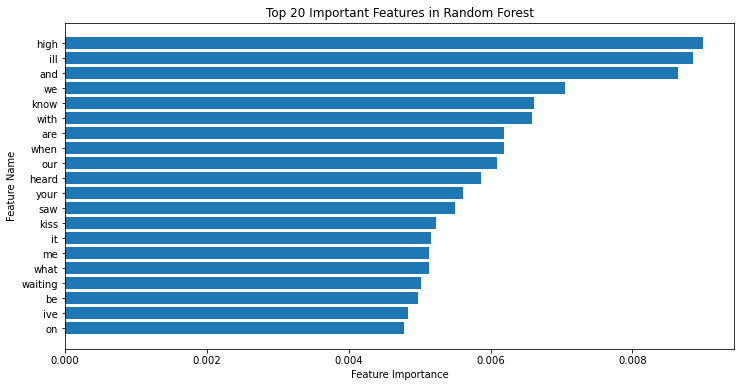

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance scores
feature_importances = final_model.feature_importances_
feature_names = tfidf_vec.get_feature_names_out()

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1][:20]  # Top 20 features

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_indices)), feature_importances[sorted_indices], align='center')
plt.yticks(range(len(sorted_indices)), [feature_names[i] for i in sorted_indices])
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Top 20 Important Features in Random Forest")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

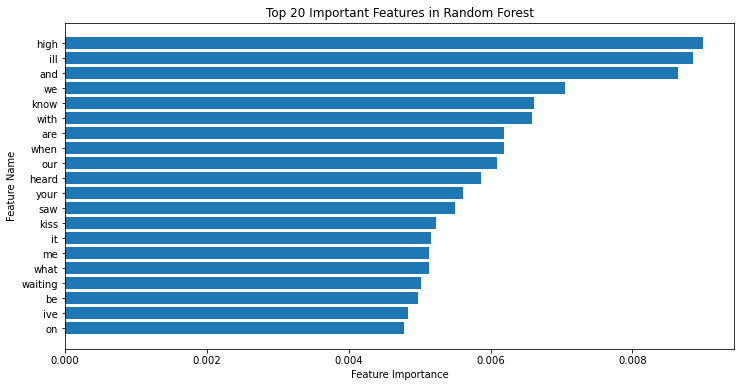

In [84]:
import matplotlib.pyplot as plt
import numpy as np

random_tree1 = RandomForestClassifier(**final_best_params, random_state=42)
random_tree1.fit(rando_woods_vecd, y)

# Get feature importance scores
feature_importances = random_tree1.feature_importances_
feature_names = tfidf_vec.get_feature_names_out()

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1][:20]  # Top 20 features

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.barh(range(len(sorted_indices)), feature_importances[sorted_indices], align='center')
plt.yticks(range(len(sorted_indices)), [feature_names[i] for i in sorted_indices])
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Top 20 Important Features in Random Forest")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

In [85]:
rando_woods = swift_db["Lyrics"]

#Rewrite custom stop words list
custom_stop_words2 = ['outro', 'bridge', 'chorus', 'intro', 'verse2', 'prechorus', 'postchorus', 'likebridge',
                      'verse', 'verse1', 'likechorus', 'pre-chorus', 'taylor swift', 'and', 'are', 'what', 'it',
                     'be', 'on']
#Use tfidf on the lyrics data
tfidf_vec = TfidfVectorizer(stop_words=custom_stop_words2)
rando_woods_vecd = tfidf_vec.fit_transform(rando_woods).toarray()

#encode labels
label_encoder = LabelEncoder()
#Apply to basic/binary labels first to get a base measurement for comparison
y=label_encoder.fit_transform(swift_db["Sentiment_Basic"])

#Call random forest model
random_tree = RandomForestClassifier(n_estimators=100, random_state=42)

#Apply cross validation to the model
cross_val_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=10, scoring="accuracy")
loo_cv_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=loo, scoring='accuracy')

#get mean accuracy
cross_val_rando_mean = np.mean(cross_val_rando)
loo_cv_rando = np.mean(loo_cv_rando)

#print the results
print(f"Accuracy for Random Forest using 10-Fold Cross Validation w/Basic Labels: {cross_val_rando_mean:.4f}")
print(f"Accuracy for Random Forest using LOO CV on Basic Labels: {loo_cv_rando:4f}")

C:\Users\super\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['pre', 'swift', 'taylor'] not in stop_words.
  warnings.warn(


Accuracy for Random Forest using 10-Fold Cross Validation w/Basic Labels: 0.5835
Accuracy for Random Forest using LOO CV on Basic Labels: 0.583942


In [86]:
#Make another Random Forest model but use the intermediate labels as opposed to the basic labels 
#to get a measurement for comparison to previous models 
rando_woods = swift_db["Lyrics"]

#Rewrite custom stop words list
custom_stop_words2 = ['outro', 'bridge', 'chorus', 'intro', 'verse2', 'prechorus', 'postchorus', 'likebridge', 'verse', 'verse1', 'likechorus', 'pre-chorus', 'taylor swift']
#Use tfidf on the lyrics data
tfidf_vec = TfidfVectorizer(stop_words=custom_stop_words2)
rando_woods_vecd = tfidf_vec.fit_transform(rando_woods).toarray()

#encode labels
label_encoder = LabelEncoder()
#Apply to basic/binary labels first to get a base measurement for comparison
y=label_encoder.fit_transform(swift_db["Sentiment_Intermediate"])

#Call random forest model
random_tree = RandomForestClassifier(n_estimators=100, random_state=42)

#Apply cross validation to the model
cross_val_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=10, scoring="accuracy")
loo_cv_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=loo, scoring='accuracy')

#get mean accuracy
cross_val_rando_mean = np.mean(cross_val_rando)
loo_cv_rando = np.mean(loo_cv_rando)

#print the results
print(f"Accuracy for Random Forest using 10-Fold Cross Validation w/Intermediate Labels: {cross_val_rando_mean:.4f}")
print(f"Accuracy for Random Forest using LOO CV on Intermediate Labels: {loo_cv_rando:4f}")

C:\Users\super\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['pre', 'swift', 'taylor'] not in stop_words.
  warnings.warn(
C:\Users\super\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


Accuracy for Random Forest using 10-Fold Cross Validation w/Intermediate Labels: 0.2989
Accuracy for Random Forest using LOO CV on Intermediate Labels: 0.226277


In [87]:
#Make model using intermediate labels and the optimal hyper parameters from previous grid search
rando_woods = swift_db["Lyrics"]

#Rewrite custom stop words list
custom_stop_words2 = ['outro', 'bridge', 'chorus', 'intro', 'verse2', 'prechorus', 'postchorus', 'likebridge', 'verse', 'verse1', 'likechorus', 'pre-chorus', 'taylor swift']
#Use tfidf on the lyrics data
tfidf_vec = TfidfVectorizer(stop_words=custom_stop_words2)
rando_woods_vecd = tfidf_vec.fit_transform(rando_woods).toarray()

#encode labels
label_encoder = LabelEncoder()
#Apply to basic/binary labels first to get a base measurement for comparison
y=label_encoder.fit_transform(swift_db["Sentiment_Intermediate"])

#Call random forest model
random_tree = RandomForestClassifier(bootstrap=True, max_depth=30, max_features="sqrt", n_estimators=216, random_state=42, min_samples_leaf=1, min_samples_split=2)

#Apply cross validation to the model
cross_val_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=10, scoring="accuracy")
loo_cv_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=loo, scoring='accuracy')

#get mean accuracy
cross_val_rando_mean = np.mean(cross_val_rando)
loo_cv_rando = np.mean(loo_cv_rando)

#print the results
print(f"Accuracy for Random Forest using 10-Fold Cross Validation w/Intermediate Labels: {cross_val_rando_mean:.4f}")
print(f"Accuracy for Random Forest using LOO CV on Intermediate Labels: {loo_cv_rando:4f}")

C:\Users\super\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['pre', 'swift', 'taylor'] not in stop_words.
  warnings.warn(
C:\Users\super\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


Accuracy for Random Forest using 10-Fold Cross Validation w/Intermediate Labels: 0.2912
Accuracy for Random Forest using LOO CV on Intermediate Labels: 0.262774


In [88]:
#hmmmm......
#...........
#..crap. 

#So....something I should have checked during the initial EDA.
#May be possible that the most frequent words for each label may appear for multiple labels.
#That is, words may share significance in both classes which makes differentiating between labels correctly 
# difficult. Need to see what the word frequency looks like both in the data and in the model to see if this 
# is true. If this is true, then may have to strip down data to certain key words, but not sure how 
#aggresive one would need to be before seeing an improvement or degrading the model in the attempt. 

#To kick off this process going to rerun the base case since ive been lazy and have been overwriting my variables
rando_woods = swift_db["Lyrics"]

#Rewrite custom stop words list
custom_stop_words2 = ['outro', 'bridge', 'chorus', 'intro', 'verse2', 'prechorus', 'postchorus', 'likebridge', 'verse', 'verse1', 'likechorus', 'pre-chorus', 'taylor swift']
#Use tfidf on the lyrics data
tfidf_vec = TfidfVectorizer(stop_words=custom_stop_words2)
rando_woods_vecd = tfidf_vec.fit_transform(rando_woods).toarray()

#encode labels
label_encoder = LabelEncoder()
#Apply to basic/binary labels first to get a base measurement for comparison
y=label_encoder.fit_transform(swift_db["Sentiment_Basic"])

#Call random forest model
random_tree = RandomForestClassifier(n_estimators=100, random_state=42)

#Apply cross validation to the model
cross_val_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=10, scoring="accuracy")
loo_cv_rando = cross_val_score(random_tree, rando_woods_vecd, y, cv=loo, scoring='accuracy')

#get mean accuracy
cross_val_rando_mean = np.mean(cross_val_rando)
loo_cv_rando = np.mean(loo_cv_rando)

#print the results
print(f"Accuracy for Random Forest using 10-Fold Cross Validation w/Basic Labels: {cross_val_rando_mean:.4f}")
print(f"Accuracy for Random Forest using LOO CV on Basic Labels: {loo_cv_rando:4f}")


C:\Users\super\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['pre', 'swift', 'taylor'] not in stop_words.
  warnings.warn(


Accuracy for Random Forest using 10-Fold Cross Validation w/Basic Labels: 0.6126
Accuracy for Random Forest using LOO CV on Basic Labels: 0.583942


In [91]:
#Then, we will use permuation importance for each label to try and determine if words are common across labels
from sklearn.inspection import permutation_importance

#Fit model
random_tree.fit(rando_woods_vecd, y)

#Compute the permutation importance for each word
perm_import = permutation_importance(random_tree, rando_woods_vecd, y, scoring="accuracy")

#sort the permuations by importance
sorted_perm_import = np.argsort(perm_import.importances_mean)[::-1]

#Print the top 40 words per label 
print("Top 40 Words Contributing to Label:")
for i in range(40):
    print(f"{feature_names[sorted_perm_import[i]]}: {perm_import.importances_mean[sorted_perm_import[i]]:4f}")

Top 40 Words Contributing to Label:
youve: 0.000000
free: 0.000000
friendsyoureout: 0.000000
friendship: 0.000000
friends: 0.000000
friend: 0.000000
friday: 0.000000
friction: 0.000000
freshman: 0.000000
fresh: 0.000000
freezing: 0.000000
freeflowing: 0.000000
freedom: 0.000000
freckles: 0.000000
from: 0.000000
frames: 0.000000
fragile: 0.000000
foyer: 0.000000
foxes: 0.000000
four: 0.000000
found: 0.000000
fought: 0.000000
forward: 0.000000
fortune: 0.000000
forts: 0.000000
forth: 0.000000
frightful: 0.000000
front: 0.000000
gate: 0.000000
furniture: 0.000000
gardn: 0.000000
gardens: 0.000000
garden: 0.000000
games: 0.000000
game: 0.000000
gain: 0.000000
g5: 0.000000
future: 0.000000
fuse: 0.000000
fury: 0.000000


In [92]:
#Check contributions to each label
# Get class-wise feature importances
feature_importances_classwise = random_tree.feature_importances_

# Separate positive and negative label importance (assuming 0 = Negative, 1 = Positive)
top_negative_words = np.argsort(feature_importances_classwise)[:10]  # Least contributing to Positive
top_positive_words = np.argsort(feature_importances_classwise)[-10:]  # Most contributing to Positive

# Print results
print("Top words for Negative Sentiment:")
for word_index in top_negative_words:
    print(feature_names[word_index])

print("\nTop words for Positive Sentiment:")
for word_index in top_positive_words:
    print(feature_names[word_index])

Top words for Negative Sentiment:
15
pace
paced
paces
pacing
pack
packed
packus
padding
owns

Top words for Positive Sentiment:
saw
waiting
your
on
know
and
our
we
ill
high


In [97]:
#hmmm, not the smoking gun I was hoping for but this is just the top 10.
#All the same, perhaps there is a better way
#We also need to take a look at the raw data and see if there is an issue
#First lets check the raw data and see what it shows us

from collections import Counter

#Seperate lyrics based on label
pos_lyrics = swift_db[swift_db["Sentiment_Basic"]=="positive"]["NLTK_Tokenized_Cstm_Stpwds"]
neg_lyrics = swift_db[swift_db["Sentiment_Basic"]=="negative"]["NLTK_Tokenized_Cstm_Stpwds"]

#Flatten words into a long list
pos_words = [word for sublist in pos_lyrics for word in sublist]
neg_words = [word for sublist in neg_lyrics for word in sublist]

#Get the most common words
common_pos = Counter(pos_words).most_common(20)
common_neg = Counter(neg_words).most_common(20)

#Print results
print("Most Common Words in Postive Sentiment:")
print(common_pos)

print("Most Common Words in Negative Sentiment:")
print(common_neg)

Most Common Words in Postive Sentiment:
[('i', 1007), ('you', 985), ('the', 821), ('and', 716), ('to', 362), ('a', 361), ('me', 353), ('my', 351), ('it', 334), ('in', 298), ('of', 245), ('know', 229), ('im', 224), ('your', 219), ('we', 198), ('like', 195), ('but', 194), ('all', 192), ('be', 184), ('oh', 180)]
Most Common Words in Negative Sentiment:
[('you', 1370), ('i', 1144), ('the', 906), ('and', 689), ('me', 529), ('to', 505), ('a', 478), ('in', 438), ('it', 414), ('my', 374), ('that', 309), ('your', 297), ('of', 287), ('but', 244), ('this', 234), ('like', 233), ('all', 229), ('im', 226), ('we', 225), ('was', 219)]


In [99]:
#Going to see if removing all 20 of these words will make a difference in perfomance
#These words should be removed by the tokenizer though. Will double check base tokenized words

#Seperate lyrics based on label
pos_lyrics = swift_db[swift_db["Sentiment_Basic"]=="positive"]["NLTK_Tokenized"]
neg_lyrics = swift_db[swift_db["Sentiment_Basic"]=="negative"]["NLTK_Tokenized"]

#Flatten words into a long list
pos_words = [word for sublist in pos_lyrics for word in sublist]
neg_words = [word for sublist in neg_lyrics for word in sublist]

#Get the most common words
common_pos = Counter(pos_words).most_common(20)
common_neg = Counter(neg_words).most_common(20)

#Print results
print("Most Common Words in Postive Sentiment:")
print(common_pos)

print("Most Common Words in Negative Sentiment:")
print(common_neg)

Most Common Words in Postive Sentiment:
[('know', 229), ('im', 224), ('like', 195), ('oh', 180), ('na', 150), ('dont', 133), ('youre', 115), ('never', 113), ('love', 109), ('one', 99), ('time', 93), ('want', 89), ('wan', 87), ('yeah', 87), ('cause', 82), ('thats', 76), ('got', 73), ('could', 71), ('say', 71), ('ill', 69)]
Most Common Words in Negative Sentiment:
[('like', 233), ('im', 226), ('never', 175), ('youre', 168), ('know', 156), ('dont', 151), ('oh', 146), ('love', 141), ('cause', 130), ('time', 120), ('back', 119), ('think', 109), ('na', 97), ('got', 95), ('one', 88), ('might', 87), ('see', 85), ('2', 84), ('say', 82), ('would', 82)]


In [103]:
#Ok, so we have some different words, but we have the same problem where both labels contain 
# many if not all the same words. The counts are much lower, but still potentially causing an issue
# given the overall size of the dataset
#So, we will go through, add the words that are in both list to the stop word list and then rerun to see
#what we get, and then repeat if necessary
#Depeding on what happens to performance will double check model list as before to ensure uunique values

stopwords_add = set([
    "know", "im", "like", "oh", "na", "dont", "youre", "never", "love", "one", "time", "cause", "got", 
    "say"
])

#Add modified list to the tokenized data
swift_db["NLTK_Tokenized_Mod"] = swift_db["NLTK_Tokenized"].apply(
    lambda tokens: [word for word in tokens if word.lower() not in stopwords_add])

In [104]:
#Now rerun and check list
pos_lyrics = swift_db[swift_db["Sentiment_Basic"]=="positive"]["NLTK_Tokenized_Mod"]
neg_lyrics = swift_db[swift_db["Sentiment_Basic"]=="negative"]["NLTK_Tokenized_Mod"]

#Flatten words into a long list
pos_words = [word for sublist in pos_lyrics for word in sublist]
neg_words = [word for sublist in neg_lyrics for word in sublist]

#Get the most common words
common_pos = Counter(pos_words).most_common(20)
common_neg = Counter(neg_words).most_common(20)

#Print results
print("Most Common Words in Postive Sentiment:")
print(common_pos)

print("Most Common Words in Negative Sentiment:")
print(common_neg)


Most Common Words in Postive Sentiment:
[('want', 89), ('wan', 87), ('yeah', 87), ('thats', 76), ('could', 71), ('ill', 69), ('see', 68), ('gon', 66), ('might', 66), ('baby', 65), ('2', 64), ('back', 62), ('also', 57), ('think', 57), ('go', 57), ('new', 57), ('shake', 56), ('cant', 55), ('take', 55), ('ive', 54)]
Most Common Words in Negative Sentiment:
[('back', 119), ('think', 109), ('might', 87), ('see', 85), ('2', 84), ('would', 82), ('wish', 78), ('look', 76), ('right', 75), ('also', 74), ('get', 73), ('baby', 73), ('yet', 68), ('go', 67), ('wan', 67), ('made', 65), ('cant', 65), ('ohoh', 63), ('could', 62), ('said', 62)]


In [105]:
#Repeat stopword list modification

stopwords_add2 = set([
    "wan", "could", "see", "baby", "2", "back", "go", "cant"
])

#Add modified list to the tokenized data
swift_db["NLTK_Tokenized_Mod"] = swift_db["NLTK_Tokenized_Mod"].apply(
    lambda tokens: [word for word in tokens if word.lower() not in stopwords_add2])

In [106]:
pos_lyrics = swift_db[swift_db["Sentiment_Basic"]=="positive"]["NLTK_Tokenized_Mod"]
neg_lyrics = swift_db[swift_db["Sentiment_Basic"]=="negative"]["NLTK_Tokenized_Mod"]

#Flatten words into a long list
pos_words = [word for sublist in pos_lyrics for word in sublist]
neg_words = [word for sublist in neg_lyrics for word in sublist]

#Get the most common words
common_pos = Counter(pos_words).most_common(20)
common_neg = Counter(neg_words).most_common(20)

#Print results
print("Most Common Words in Postive Sentiment:")
print(common_pos)

print("Most Common Words in Negative Sentiment:")
print(common_neg)

Most Common Words in Postive Sentiment:
[('want', 89), ('yeah', 87), ('thats', 76), ('ill', 69), ('gon', 66), ('might', 66), ('also', 57), ('think', 57), ('new', 57), ('shake', 56), ('take', 55), ('ive', 54), ('said', 50), ('ever', 50), ('ooh', 50), ('stay', 49), ('way', 48), ('still', 47), ('night', 46), ('home', 46)]
Most Common Words in Negative Sentiment:
[('think', 109), ('might', 87), ('would', 82), ('wish', 78), ('look', 76), ('right', 75), ('also', 74), ('get', 73), ('yet', 68), ('made', 65), ('ohoh', 63), ('said', 62), ('id', 62), ('taylor', 61), ('stay', 60), ('tell', 58), ('didnt', 58), ('swift', 57), ('ever', 57), ('red', 56)]


In [109]:
#And one more time for good luck
stopwords_add3 = set([
    "might", "also", "get", "said", "ever", "stay"
])

#Add modified list to the tokenized data
swift_db["NLTK_Tokenized_Mod"] = swift_db["NLTK_Tokenized_Mod"].apply(
    lambda tokens: [word for word in tokens if word.lower() not in stopwords_add3])

In [110]:
pos_lyrics = swift_db[swift_db["Sentiment_Basic"]=="positive"]["NLTK_Tokenized_Mod"]
neg_lyrics = swift_db[swift_db["Sentiment_Basic"]=="negative"]["NLTK_Tokenized_Mod"]

#Flatten words into a long list
pos_words = [word for sublist in pos_lyrics for word in sublist]
neg_words = [word for sublist in neg_lyrics for word in sublist]

#Get the most common words
common_pos = Counter(pos_words).most_common(20)
common_neg = Counter(neg_words).most_common(20)

#Print results
print("Most Common Words in Postive Sentiment:")
print(common_pos)

print("Most Common Words in Negative Sentiment:")
print(common_neg)

Most Common Words in Postive Sentiment:
[('want', 89), ('yeah', 87), ('thats', 76), ('ill', 69), ('gon', 66), ('think', 57), ('new', 57), ('shake', 56), ('take', 55), ('ive', 54), ('ooh', 50), ('way', 48), ('still', 47), ('night', 46), ('home', 46), ('girl', 46), ('first', 45), ('waiting', 42), ('good', 42), ('dancing', 42)]
Most Common Words in Negative Sentiment:
[('think', 109), ('would', 82), ('wish', 78), ('look', 76), ('right', 75), ('yet', 68), ('made', 65), ('ohoh', 63), ('id', 62), ('taylor', 61), ('tell', 58), ('didnt', 58), ('swift', 57), ('red', 56), ('want', 56), ('around', 55), ('bad', 55), ('yeah', 55), ('man', 51), ('good', 49)]


In [112]:
#Lets see what impact if any this has on the random forest model ran previously
# Join tokenized words into text again for TF-IDF
swift_db["NLTK_Tokenized_Joined"] = swift_db["NLTK_Tokenized_Mod"].apply(lambda tokens: " ".join(tokens))

# Initialize TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(max_features=5000, stop_words="english")  # Adjust max_features if needed
X = tfidf_vec.fit_transform(swift_db["NLTK_Tokenized_Joined"]).toarray()

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(swift_db["Sentiment_Basic"])

# Train Random Forest
random_tree = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform 10-Fold Cross Validation
cv_scores = cross_val_score(random_tree, X, y, cv=10, scoring="accuracy")

# Print accuracy
print(f"10-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

10-Fold CV Accuracy: 0.5758 ± 0.0842


In [133]:
#Optimal model rerun 
swift_db["NLTK_Tokenized_Joined"] = swift_db["NLTK_Tokenized_Mod"].apply(lambda tokens: " ".join(tokens))

# Initialize TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(max_features=5000, stop_words="english")  # Adjust max_features if needed
X = tfidf_vec.fit_transform(swift_db["NLTK_Tokenized_Joined"]).toarray()

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(swift_db["Sentiment_Basic"])

# Train Random Forest
random_tree = RandomForestClassifier(bootstrap=True, max_depth=30, max_features="sqrt", n_estimators=216, random_state=42, min_samples_leaf=1, min_samples_split=2)



# Perform 10-Fold Cross Validation
cv_scores = cross_val_score(random_tree, X, y, cv=40, scoring="accuracy")

# Print accuracy
print(f"10-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

10-Fold CV Accuracy: 0.6271 ± 0.2415


In [138]:
from sklearn.metrics.pairwise import cosine_similarity

# Convert tokenized text back into strings
swift_db["NLTK_Tokenized_Joined"] = swift_db["NLTK_Tokenized_Mod"].apply(lambda tokens: " ".join(tokens))

# Apply TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf_vec.fit_transform(swift_db["NLTK_Tokenized_Joined"])

# Compute cosine similarity matrix
cosine_sim_matrix = cosine_similarity(tfidf_matrix)

# Convert to DataFrame for easier visualization
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=swift_db.index, columns=swift_db.index)

# Print first 5 rows to check results
print(cosine_sim_df.head())

# Save to CSV for further inspection
cosine_sim_df.to_csv("cosine_similarity.csv")

        0         1         2         3         4         5         6    \
0  1.000000  0.002686  0.014506  0.001608  0.015542  0.018980  0.021389   
1  0.002686  1.000000  0.002897  0.006426  0.017161  0.010111  0.019536   
2  0.014506  0.002897  1.000000  0.012417  0.016067  0.130895  0.024455   
3  0.001608  0.006426  0.012417  1.000000  0.027932  0.010077  0.029947   
4  0.015542  0.017161  0.016067  0.027932  1.000000  0.009098  0.014679   

        7         8         9    ...       127       128       129       130  \
0  0.029605  0.020870  0.015340  ...  0.010357  0.018519  0.032296  0.002773   
1  0.005029  0.007764  0.024425  ...  0.000000  0.016253  0.000000  0.014605   
2  0.036964  0.014531  0.018805  ...  0.012200  0.005708  0.008572  0.007481   
3  0.022551  0.043987  0.011717  ...  0.008248  0.014140  0.016415  0.014484   
4  0.015329  0.018289  0.003845  ...  0.010762  0.003142  0.010377  0.006167   

        131       132       133       134       135       136  
0  0

In [139]:
from sklearn.metrics import jaccard_score

# Convert tokenized lists to sets
swift_db["Token_Set"] = swift_db["NLTK_Tokenized_Mod"].apply(set)

# Function to compute Jaccard similarity between two rows
def jaccard_similarity(row1, row2):
    intersection = len(row1.intersection(row2))
    union = len(row1.union(row2))
    return intersection / union if union != 0 else 0

# Compute Jaccard Similarity for all rows
jaccard_matrix = pd.DataFrame(
    [[jaccard_similarity(row1, row2) for row2 in swift_db["Token_Set"]]
     for row1 in swift_db["Token_Set"]],
    index=swift_db.index, columns=swift_db.index
)

# Print first few rows
print(jaccard_matrix.head())

# Save to CSV
jaccard_matrix.to_csv("jaccard_similarity.csv")

        0         1         2         3         4         5         6    \
0  1.000000  0.006369  0.043689  0.005464  0.040936  0.042328  0.027027   
1  0.006369  1.000000  0.019737  0.016393  0.035088  0.030075  0.040000   
2  0.043689  0.019737  1.000000  0.022599  0.035503  0.026455  0.033149   
3  0.005464  0.016393  0.022599  1.000000  0.051095  0.018750  0.026316   
4  0.040936  0.035088  0.035503  0.051095  1.000000  0.032895  0.027397   

        7         8         9    ...       127       128       129       130  \
0  0.046948  0.029703  0.024510  ...  0.034483  0.040816  0.030303  0.024242   
1  0.018750  0.027778  0.020548  ...  0.008403  0.044944  0.000000  0.038095   
2  0.057692  0.035354  0.024876  ...  0.041176  0.020408  0.024540  0.050633   
3  0.038462  0.054545  0.029412  ...  0.020979  0.017094  0.030303  0.054688   
4  0.028090  0.024390  0.011976  ...  0.029412  0.018018  0.040000  0.040323   

        131       132       133       134       135       136  
0  0

In [140]:
#Check the unmodified text data
# Convert tokenized lists to sets
swift_db["Token_Set"] = swift_db["NLTK_Tokenized"].apply(set)

# Function to compute Jaccard similarity between two rows
def jaccard_similarity(row1, row2):
    intersection = len(row1.intersection(row2))
    union = len(row1.union(row2))
    return intersection / union if union != 0 else 0

# Compute Jaccard Similarity for all rows
jaccard_matrix = pd.DataFrame(
    [[jaccard_similarity(row1, row2) for row2 in swift_db["Token_Set"]]
     for row1 in swift_db["Token_Set"]],
    index=swift_db.index, columns=swift_db.index
)

# Print first few rows
print(jaccard_matrix.head())

# Save to CSV
jaccard_matrix.to_csv("jaccard_similarity.csv")

        0         1         2         3         4         5         6    \
0  1.000000  0.034286  0.070796  0.054455  0.073298  0.067961  0.059406   
1  0.034286  1.000000  0.052941  0.071429  0.075758  0.060811  0.070922   
2  0.070796  0.052941  1.000000  0.060302  0.068421  0.063415  0.060000   
3  0.054455  0.071429  0.060302  1.000000  0.108280  0.055866  0.063953   
4  0.073298  0.075758  0.068421  0.108280  1.000000  0.052326  0.060606   

        7         8         9    ...       127       128       129       130  \
0  0.068966  0.054299  0.044248  ...  0.077720  0.084337  0.070652  0.086957   
1  0.057143  0.075949  0.061350  ...  0.058394  0.114286  0.055118  0.078740   
2  0.093333  0.059633  0.058824  ...  0.078534  0.065868  0.059783  0.087912   
3  0.074257  0.091892  0.067708  ...  0.092593  0.071942  0.070968  0.126667   
4  0.060914  0.054348  0.064865  ...  0.076433  0.093023  0.082192  0.118056   

        131       132       133       134       135       136  
0  0

In [141]:

# Exclude diagonal (self-similarity)
cosine_sim_mean = np.mean(cosine_sim_matrix[np.triu_indices_from(cosine_sim_matrix, k=1)])

print(f"Mean Cosine Similarity Score: {cosine_sim_mean:.4f}")

Mean Cosine Similarity Score: 0.0261


In [142]:
# Exclude diagonal
jaccard_sim_mean = np.mean(jaccard_matrix.to_numpy()[np.triu_indices_from(jaccard_matrix, k=1)])

print(f"Mean Jaccard Similarity Score: {jaccard_sim_mean:.4f}")

Mean Jaccard Similarity Score: 0.0824
